# Assessment 2: Machine Learning and Real-Time Streaming

**Student ID:** 35721588  
**Unit:** ITO5202  
**Teaching Period:** 5, 2026

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Source:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In Assessment 1, we analysed historical freight charges across Olist shipping lanes. Now, in this task we want to build on that work using the same dataset. Firstly, in Part A, we look to train a model to predict the freight charged on each order item. Then, later in Part B, we want to be able to apply the saved model to orders it has not seen.

---

## Contents

**Setup**
- Environment and configuration
- Data loading
- Building the modelling dataset
- Train/stream split
- Exploring the target: freight value

**Part A: Machine learning pipeline**
1. ML task selection
2. Feature engineering
3. Model comparison and evaluation
4. Model persistence and verification

**Part B: Streaming, Kafka and reflection**
1. Streaming data simulation and Kafka producer
2. Structured Streaming consumer
3. Windowed aggregation
4. Reflection

---

## Environment and configuration

### Execution environment

Similar to what we did previously in Assessment 1, we want to run Spark in local mode on a single laptop, with its four logical cores acting as parallel task slots. The key difference for us now in this assessment is that a Kafka broker and ZooKeeper also run on the same machine during Part B. 

As we note in the below table, all three share the 8GB of memory. As such, Kafka's memory is capped at 512MB in order to leave enough room for Spark.

| Property | Value |
|---|---|
| Machine | MacBook Air (Retina, 13-inch, 2018) |
| Processor | 1.6 GHz dual-core Intel Core i5 |
| Logical cores | 4 |
| Physical memory | 8 GB |
| Operating system | macOS Sonoma 14.7.8 |
| Java | Eclipse Temurin JDK 17 (x64) |
| Python | 3.11.9 |
| PySpark | 3.5.1 |
| Kafka | 3.9.2 (ZooKeeper mode) |
| Spark master | `local[*]` |

In [62]:
# Import packages
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

import numpy as np
import matplotlib.pyplot as plt

from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (SQLTransformer, Imputer, StringIndexer,
                                OneHotEncoder, VectorAssembler, StandardScaler)

from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import time
import shutil

# File locations
DATA_DIR = "data/raw"
STREAM_PATH = "data/stream_data.parquet"
MODEL_PATH = "models/a2_model"

# Random seed for the train/stream split + model training
SEED = 42

### SparkSession configuration

In order for us to be able to complete the tasks needed for this assessment within our local set up, there were a few key Spark settings that we first made changes to. These are:

**`spark.driver.memory = 3g`**

Given that our notebook is running Spark in local mode, the driver is therefore doing the processing on the laptop itself. As such, we wanted to give Spark 3GB of memory rather than letting allowing for it to consume too much memory. 
This decision was made due to the fact that the laptop has 8 GB in available memory, and our later tasks in Part B need Kafka and ZooKeeper running alongside Spark. Because of this, leaving some memory free for those processes was critical.

**`spark.sql.shuffle.partitions = 4`**

Similar to our decision in Assessment 1, this setting was again set to 4. We note that the normal Spark default is 200 partitions, which is excessive for our dataset, which only has ~110,000 rows and would create lots of tiny tasks unneccesarily.

Furthermore, this decision also matters for our streaming section of this assessment. The shuffle partition setting is used by Spark when maintaining aggregation state, so using 200 partitions would mean each micro-batch has much more scheduling overhead. On the other hand, four partitions is more appropriate for the small local setup being used here.

**`spark.sql.session.timeZone = UTC`**

UTC is used here so that the timestamp handling stays consistent between runs rather than depending on the laptop's local time settings. This is particularly useful in Part B because the produced Kafka records contain timestamps.

It also avoids issues caused by Sydney changing between standard time and daylight saving time.

**`spark.jars.packages`**

We needed to add the Kafka connector separately due to the fact that it is not included in the normal PySpark installation. The connector version is matched to the Spark/PySpark version being used.

**Adaptive Query Execution**

AQE has not been manually disabled for this assessment, so Spark keeps its normal default behaviour.

In our previous assessment, AQE was turned off because the physical execution plans were being examined and needed to stay predictable. Given that this is not required here, there was no particular need for us to disable it. We note that AQE also does not apply to the streaming query itself, meaning it is only relevant to our batch work in Part A.

In [63]:
# Start building the Spark session
builder = SparkSession.builder

# Basic session settings
builder = builder.appName("ITO5202-A2-Olist-Freight")
builder = builder.master("local[*]")

# Memory and partition settings
builder = builder.config("spark.driver.memory", "3g")
builder = builder.config("spark.sql.shuffle.partitions", 4)

# Keep timestamps consistent
builder = builder.config("spark.sql.session.timeZone", "UTC")

# Add the Kafka connector
builder = builder.config(
    "spark.jars.packages",
    "org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.1"
)

# Create the session
spark = builder.getOrCreate()

# Reduce console logging
spark.sparkContext.setLogLevel("ERROR")

spark

In [64]:
# Get the Spark context
sc = spark.sparkContext

# Check the main environment settings
print("Spark version:", spark.version)
print("Master:", sc.master)
print("Task slots:", sc.defaultParallelism)

# Check the configured values
print("Driver memory:", spark.conf.get("spark.driver.memory"))
print("Shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))
print("AQE:", spark.conf.get("spark.sql.adaptive.enabled"))
print("Time zone:", spark.conf.get("spark.sql.session.timeZone"))
print("Kafka package:", spark.conf.get("spark.jars.packages"))

Spark version: 3.5.1
Master: local[*]
Task slots: 4
Driver memory: 3g
Shuffle partitions: 4
AQE: true
Time zone: UTC
Kafka package: org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.1


---

## Data loading

### Schemas

The seven CSV files that we need for our analysis are loaded with schemas written out manually instead of using `inferSchema=True`.

We note that it is particularly important for us to do this due to two key reasons:

1. Spark needs to inspect the data first when it infers a schema, which means another pass over the files before the actual load. This is unneccesary (and inefficient) for our use case, especially for the geolocation file which has over one million rows.

2. By using fixed schemas, we are also able to make the data types more predictable. Columns used across multiple tables, such as `order_id` and `product_id`, are defined the same way each time, which helps us to avoid type problems later on during joins.

We should also note again that the payments and reviews files are not used in this project. This is due to the fact that reviews only exist after an order has been delivered, and as such they would not be known, or relevant when freight is calculated. Also, payment values are also not used because they already include freight as part of the total amount paid. We consider these exclusions and our reasoning in more detail later in Part A.

### Correcting source column names

We note that there are two spelling mistakes in the original products CSV headers: `product_name_lenght` and `product_description_lenght`.

The initial schema still needs to use those exact names so Spark can read the file correctly. After the file is loaded, we can correct these column names.

In [65]:
# Schemas for the seven CSV files
order_items_schema = StructType([
    StructField("order_id", StringType(), False),
    StructField("order_item_id", IntegerType(), False),
    StructField("product_id", StringType(), True),
    StructField("seller_id", StringType(), True),
    StructField("shipping_limit_date", TimestampType(), True),
    StructField("price", DoubleType(), True),
    StructField("freight_value", DoubleType(), True)
])

orders_schema = StructType([
    StructField("order_id", StringType(), False),
    StructField("customer_id", StringType(), False),
    StructField("order_status", StringType(), True),
    StructField("order_purchase_timestamp", TimestampType(), True),
    StructField("order_approved_at", TimestampType(), True),
    StructField("order_delivered_carrier_date", TimestampType(), True),
    StructField("order_delivered_customer_date", TimestampType(), True),
    StructField("order_estimated_delivery_date", TimestampType(), True)
])

customers_schema = StructType([
    StructField("customer_id", StringType(), False),
    StructField("customer_unique_id", StringType(), True),
    StructField("customer_zip_code_prefix", IntegerType(), True),
    StructField("customer_city", StringType(), True),
    StructField("customer_state", StringType(), True)
])

sellers_schema = StructType([
    StructField("seller_id", StringType(), False),
    StructField("seller_zip_code_prefix", IntegerType(), True),
    StructField("seller_city", StringType(), True),
    StructField("seller_state", StringType(), True)
])

geolocation_schema = StructType([
    StructField("geolocation_zip_code_prefix", IntegerType(), True),
    StructField("geolocation_lat", DoubleType(), True),
    StructField("geolocation_lng", DoubleType(), True),
    StructField("geolocation_city", StringType(), True),
    StructField("geolocation_state", StringType(), True)
])

products_schema = StructType([
    StructField("product_id", StringType(), False),
    StructField("product_category_name", StringType(), True),
    StructField("product_name_lenght", IntegerType(), True),
    StructField("product_description_lenght", IntegerType(), True),
    StructField("product_photos_qty", IntegerType(), True),
    StructField("product_weight_g", IntegerType(), True),
    StructField("product_length_cm", IntegerType(), True),
    StructField("product_height_cm", IntegerType(), True),
    StructField("product_width_cm", IntegerType(), True)
])

category_schema = StructType([
    StructField("product_category_name", StringType(), True),
    StructField("product_category_name_english", StringType(), True)
])


# Small helper for loading CSV files
def load_csv(filename, schema):
    file_path = DATA_DIR + "/" + filename

    df = spark.read \
        .option("header", "true") \
        .schema(schema) \
        .csv(file_path)

    return df


# Load each dataset
order_items = load_csv("olist_order_items_dataset.csv", order_items_schema)
orders = load_csv("olist_orders_dataset.csv", orders_schema)
customers = load_csv("olist_customers_dataset.csv", customers_schema)
sellers = load_csv("olist_sellers_dataset.csv", sellers_schema)
geolocation = load_csv("olist_geolocation_dataset.csv", geolocation_schema)
categories = load_csv("product_category_name_translation.csv", category_schema)

# Load products separately so the headers can be fixed
products = load_csv("olist_products_dataset.csv", products_schema)

# Correct the two spelling mistakes
products = products.withColumnRenamed(
    "product_name_lenght",
    "product_name_length"
)

products = products.withColumnRenamed(
    "product_description_lenght",
    "product_description_length"
)

In [66]:
# Store each dataset with its expected row count
datasets = [
    ("order_items", order_items, 112650),
    ("orders", orders, 99441),
    ("customers", customers, 99441),
    ("sellers", sellers, 3095),
    ("geolocation", geolocation, 1000163),
    ("products", products, 32951),
    ("categories", categories, 71)
]

# Build a simple validation table
rows = []

for name, df, expected in datasets:
    actual = df.count()
    number_of_columns = len(df.columns)

    row = {
        "dataset": name,
        "expected": expected,
        "actual": actual,
        "match": actual == expected,
        "columns": number_of_columns
    }

    rows.append(row)

# Display the results
count_check = pd.DataFrame(rows)

count_check

,dataset,expected,actual,match,columns
0,order_items,112650,112650,True,7
1,orders,99441,99441,True,8
2,customers,99441,99441,True,5
3,sellers,3095,3095,True,4
4,geolocation,1000163,1000163,True,5
5,products,32951,32951,True,9
6,categories,71,71,True,2


---

## Building the modelling dataset

The data that we need for our modelling comes from several separate files within the Olist dataset, so we need to first join them into one dataset with one row for each order item. This is also the level we want to use later for prediction due to the fact that in our data, freight is recorded against individual items rather than only at the order level.

While our overall set up is quite similar to what we did in Assessment 1, there are a few key differences we should note:

**Keep the original inputs**

In Assessment 1, we calculated some extra fields such as distance and package volume while our main dataset was being built. Here however, we want to instead keep the original values, such as the seller and customer coordinates and the package dimensions.

While we still want to do these calculations, we instead move them into the feature engineering pipeline later in our analysis. Fundamentally, this also makes the batch and streaming components easier to keep consistent, due to the fact that the Kafka records can contain the same raw fields and the saved pipeline can apply the same transformations to them.

**Add the number of items in each order**

We want to add a count of the items in each order to every row. This information is already available when the order is placed and may be useful because orders containing more items can have freight split differently.

**Do not create features using `freight_value`**

Some of the measures we used in Assessment 1, such as freight per kilogram and freight-to-price ratio, use `freight_value` in their calculation.

We note that we cannot do that here due t `freight_value` being the target that is being predicted. Using those fields as model inputs would leak information about the answer into the model.

**Keep missing values at this stage**

Rows with missing product, category or location values are not removed while building the dataset and instead are dealt with later inside the modelling pipeline.

This is important for us later on in Part B as well, since incoming streaming records may also have missing fields and should go through the same preparation steps as the training data.

Finally, we note that only delivered orders with a delivery date are kept, which matches our filtering decisioning used in Assessment 1. More specifically, cancelled and unavailable orders are left out because due to the fact that they did not result in a completed delivery.

### Preparing the source tables

Similar to what we did in Assessment 1, there are some important data cleaning steps that we need to take in order to ensure our datasets are usable for our analysis.

**Orders**

Our orders table is filtered to delivered orders that also have a delivery date recorded. This keeps our modelling data focused on completed shipments only without noise from cancelled orders.

**Geolocation**

Firstly, our geolocation file has multiple latitude and longitude records for the same postcode prefix. If we were to join this directly, a single order item could match several location rows and get duplicated.

To avoid that, the coordinates are averaged so there is only one row for each postcode prefix. This smaller lookup table is cached so it can be leveraged for later analysis.

**Category translations**

Our category translation file is also checked before joining. Like we noted in the previous assessment, there are Portuguese category names which do not have an English translation in the supplied file. As such, these translations are added manually.

After we have do our preparation, we are able to trim them down to only the columns needed for the joins and the model.

In [67]:
# Average coordinates for each postcode prefix
geo_lookup = geolocation.groupBy("geolocation_zip_code_prefix") \
    .agg(
        F.avg("geolocation_lat").alias("lat"),
        F.avg("geolocation_lng").alias("lng")
    )

# Cache because this lookup is used twice later
geo_lookup.cache()

geo_rows = geo_lookup.count()
print("Geolocation lookup rows:", geo_rows)


# Keep completed deliveries with a delivery date
orders_delivered = orders.filter(
    F.col("order_status") == "delivered"
)

orders_delivered = orders_delivered.filter(
    F.col("order_delivered_customer_date").isNotNull()
)

delivered_rows = orders_delivered.count()
print("Delivered orders retained:", delivered_rows)


# Add the two missing category translations
extra_categories = [
    ("pc_gamer", "pc_gamer"),
    (
        "portateis_cozinha_e_preparadores_de_alimentos",
        "kitchen_portables_and_food_preparers"
    )
]

missing_categories = spark.createDataFrame(
    extra_categories,
    ["product_category_name", "product_category_name_english"]
)

# Combine them with the supplied translations
categories_complete = categories.unionByName(missing_categories)

Geolocation lookup rows: 19015
Delivered orders retained: 96470


In [68]:
# Keep the order fields needed later
orders_join = orders_delivered.select(
    "order_id",
    "customer_id",
    "order_purchase_timestamp"
)

# Keep the customer location fields
customers_join = customers.select(
    "customer_id",
    "customer_state",
    "customer_zip_code_prefix"
)

# Keep the seller location fields
sellers_join = sellers.select(
    "seller_id",
    "seller_state",
    "seller_zip_code_prefix"
)

# Keep the product fields used for modelling
products_join = products.select(
    "product_id",
    "product_category_name",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
)


# Make a customer version of the postcode lookup
customer_geo = geo_lookup.select(
    F.col("geolocation_zip_code_prefix").alias("customer_zip_code_prefix"),
    F.col("lat").alias("customer_lat"),
    F.col("lng").alias("customer_lng")
)

# Make a seller version of the same lookup
seller_geo = geo_lookup.select(
    F.col("geolocation_zip_code_prefix").alias("seller_zip_code_prefix"),
    F.col("lat").alias("seller_lat"),
    F.col("lng").alias("seller_lng")
)

### Joining the tables

Our order item table is used as the main starting point, and the other tables are joined onto it.

Importantly, we want to use inner joins for our rrders, customers and sellers utables, due to the fact that each retained item should belong to a delivered order and have a matching customer and seller.

On the other hand, we instead use left joins for products, category translations and postcode locations in order to ensure that an order item is not removed simply because one of those extra fields is missing.

Furthermore, we want to ensure that the smaller lookup tables, such as sellers, products, categories and the postcode coordinate tables, are broadcast before joining in order to avoid moving the larger order data around as much during the joins.

Finally, the total number of items in each order is also calculated from the original order items table. That count is then joined back onto each individual item so every row includes the size of its order.

In [69]:
# Count how many items are in each order
order_sizes = order_items.groupBy("order_id") \
    .agg(F.count("*").alias("order_item_count"))


# Start with the main order item data
model_df = order_items.join(
    orders_join,
    on="order_id",
    how="inner"
)

# Add customer details
model_df = model_df.join(
    customers_join,
    on="customer_id",
    how="inner"
)

# Add seller details
model_df = model_df.join(
    F.broadcast(sellers_join),
    on="seller_id",
    how="inner"
)

# Add basket size
model_df = model_df.join(
    order_sizes,
    on="order_id",
    how="inner"
)


# Add product information
model_df = model_df.join(
    F.broadcast(products_join),
    on="product_id",
    how="left"
)

# Add translated category names
model_df = model_df.join(
    F.broadcast(categories_complete),
    on="product_category_name",
    how="left"
)

# Add customer coordinates
model_df = model_df.join(
    F.broadcast(customer_geo),
    on="customer_zip_code_prefix",
    how="left"
)

# Add seller coordinates
model_df = model_df.join(
    F.broadcast(seller_geo),
    on="seller_zip_code_prefix",
    how="left"
)


# Keep only the fields needed for modelling
model_df = model_df.select(
    "order_id",
    "order_item_id",
    "order_purchase_timestamp",
    "freight_value",
    "price",
    "order_item_count",
    "seller_state",
    "customer_state",
    "seller_lat",
    "seller_lng",
    "customer_lat",
    "customer_lng",
    "product_category_name_english",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
)

# Check the final size
row_count = model_df.count()
column_count = len(model_df.columns)

print("Rows:", row_count)
print("Columns:", column_count)

Rows: 110189
Columns: 17


### Checking and caching the modelling dataset

Before we are able to use the dataset, we want to first check the joins to make sure each order item still appears only once. That is to say, we want to ensure that no duplicates were inadvertantly created.

Once our checks are completed, our completed modelling table is then cached as it is used several times later in the notebook, including for the target checks, splitting the data and training the models. By caching it, we are thus able to avoid running all of the joins again each time the dataset is used.

Finally, we want to conduct a check for any missing values. We want to be able to count these across the columns so that we are able to construct a quick view of which fields contain gaps and therefore need to be dealt with later in the feature pipeline.

In [70]:
# Check that order items were not duplicated
total_rows = model_df.count()

distinct_items = model_df.select(
    "order_id",
    "order_item_id"
).distinct().count()

print("Rows:", total_rows)
print("Distinct order items:", distinct_items)


# Cache the modelling dataset for reuse
model_df.cache()

# Run an action so the cache is populated
cached_rows = model_df.count()

print("Cached rows:", cached_rows)

Rows: 110189
Distinct order items: 110189


Cached rows: 110189


In [71]:
# Count nulls in each column
missing_counts = []

for column in model_df.columns:
    missing_count = model_df.filter(
        F.col(column).isNull()
    ).count()

    missing_counts.append({
        "column": column,
        "missing_rows": missing_count
    })

# Put the results into a small table
missing = pd.DataFrame(missing_counts)

missing

,column,missing_rows
0,order_id,0
1,order_item_id,0
2,order_purchase_timestamp,0
3,freight_value,0
4,price,0
5,order_item_count,0
6,seller_state,0
7,customer_state,0
8,seller_lat,249
9,seller_lng,249


#### Findings

We can see from our checks that the joins did not create any duplicate order items. There are 110,189 rows in the modelling dataset and 110,189 distinct combinations of `order_id` and `order_item_id`, which is consistent with our base dataset from Assessment 1.

The main identifiers that we are interested in for our analysis, `freight_value` target and order-level fields are complete. Any missing data is limited to a few fields:

- **Coordinates:** 249 rows are missing seller coordinates and 288 are missing customer coordinates.
- **Product category:** 1,537 rows do not have an English product category, which is about 1.4% of the rows.
- **Product measurements:** 18 rows are missing the product weight, length, height and width. Because the counts are the same across all four fields, these are most likely to be the same products with all physical measurements missing.

We should note that our feature pipeline in Part A, Section 2 handles these missing values before the models are trained, and as such we do not need to address any missing data at this stage.

---

## Train/stream split

Before we do any model training or analysis, we first need to split our modelling data into two components:

- **Training data (70%):** We use the training set in Part A to explore the data, train our models and evaluate their performance.
- **Streaming data (30%):** Our streaming set is kept separate and used later in Part B when our records are sent through Kafka.

We note that the streaming portion is not used in any way during model training or evaluation. This ensures that the records we use in Part B are unseen by the model beforehand.

**Split by order**

Since `order_id` values are unique, we are able to use that to perform the split of the two components rather than using individual order-item rows. We are able to apply `randomSplit([0.7, 0.3], seed=42)` to the orders first, and then all items belonging to an order are put into the same subset.

This is particularly important for us because items from the same order share a lot of information, such as the customer, seller, route and purchase date. As such, if items were split individually, one item from an order could appear in training while another item from the same order appeared in the held-out data. That would result in the two datasets being less independent and could make model performance look better than it really is.

**Fixed seed**

As we noted above, a seed of 42 is used for the split. This is done so that the same orders are assigned to each subset when the notebook is rerun with the same data.

In [72]:
# Get the unique orders first
distinct_orders = model_df.select("order_id").distinct()

# Split orders into training and streaming groups
train_orders, stream_orders = distinct_orders.randomSplit(
    [0.7, 0.3],
    seed=SEED
)

# Join the order groups back to the item-level data
train_df = model_df.join(
    train_orders,
    on="order_id",
    how="inner"
)

stream_df = model_df.join(
    stream_orders,
    on="order_id",
    how="inner"
)

# Cache both datasets for later use
train_df.cache()
stream_df.cache()

DataFrame[order_id: string, order_item_id: int, order_purchase_timestamp: timestamp, freight_value: double, price: double, order_item_count: bigint, seller_state: string, customer_state: string, seller_lat: double, seller_lng: double, customer_lat: double, customer_lng: double, product_category_name_english: string, product_weight_g: int, product_length_cm: int, product_height_cm: int, product_width_cm: int]

In [73]:
# Count rows in each subset
train_items = train_df.count()
stream_items = stream_df.count()

# Count unique orders in each subset
train_order_count = train_df.select("order_id").distinct().count()
stream_order_count = stream_df.select("order_id").distinct().count()


# Check that no order appears in both groups
train_order_ids = train_df.select("order_id").distinct()
stream_order_ids = stream_df.select("order_id").distinct()

overlap = train_order_ids.join(
    stream_order_ids,
    on="order_id",
    how="inner"
).count()


# Put the split results into a table
split_rows = [
    {
        "subset": "training",
        "orders": train_order_count,
        "items": train_items
    },
    {
        "subset": "streaming",
        "orders": stream_order_count,
        "items": stream_items
    }
]

split_summary = pd.DataFrame(split_rows)

# Calculate percentage shares
total_orders = split_summary["orders"].sum()
total_items = split_summary["items"].sum()

split_summary["order_share_%"] = (
    split_summary["orders"] / total_orders * 100
).round(2)

split_summary["item_share_%"] = (
    split_summary["items"] / total_items * 100
).round(2)


# Final checks
print("Total items:", train_items + stream_items, "(expected 110,189)")
print("Orders in both subsets:", overlap)

split_summary

26/10/05 23:59:03 ERROR MicroBatchExecution: Query freight_predictions [id = ad23f16a-cace-487d-898a-52809613765f, runId = afc71130-70f9-4961-b280-77e5a491003a] terminated with error
java.util.concurrent.ExecutionException: org.apache.kafka.common.errors.TimeoutException: Timed out waiting for a node assignment. Call: describeTopics
	at java.base/java.util.concurrent.CompletableFuture.reportGet(CompletableFuture.java:396)
	at java.base/java.util.concurrent.CompletableFuture.get(CompletableFuture.java:2073)
	at org.apache.kafka.common.internals.KafkaFutureImpl.get(KafkaFutureImpl.java:165)
	at org.apache.spark.sql.kafka010.ConsumerStrategy.retrieveAllPartitions(ConsumerStrategy.scala:66)
	at org.apache.spark.sql.kafka010.ConsumerStrategy.retrieveAllPartitions$(ConsumerStrategy.scala:65)
	at org.apache.spark.sql.kafka010.SubscribeStrategy.retrieveAllPartitions(ConsumerStrategy.scala:102)
	at org.apache.spark.sql.kafka010.SubscribeStrategy.assignedTopicPartitions(ConsumerStrategy.scala:11

Total items: 110189 (expected 110,189)
Orders in both subsets: 0


,subset,orders,items,order_share_%,item_share_%
0,training,67726,77363,70.2,70.21
1,streaming,28744,32826,29.8,29.79


**Split results**

We can see from the above that our 96,470 delivered orders were split into 67,726 training orders and 28,744 streaming orders. This gives us roughly 70.2% of orders to training and 29.8% to streaming.

At an item level, the training set contains 77,363 rows and the streaming set contains 32,826 rows, which gives proportions that are very similar to the order-level split, meaning that grouping the split by order did not noticeably impact the number of items in either subset.

Together, the two subsets contain all 110,189 order items and all 96,470 orders. Our overlap check above also returned zero, meaning that that no order appears in both datasets.

### Saving our streaming set

Our streaming data is saved to `data/stream_data.parquet` so that we can load it up again using the Kafka producer in Part B later.

Since this subset is only around 33,000 rows, it can be written as a single data file and thus allows us to keep the output simple. We use overwrite mode here so that the notebook can be rerun without needing to manually delete the old file first, which important for us as we test and iterate on our analysis.

In saying that however, given that we used a fixed seed for the split, rerunning the notebook with the same source data should produce the same streaming records regardless.

In [74]:
# Save the streaming data as one parquet file
stream_output = stream_df.coalesce(1)

stream_output.write \
    .mode("overwrite") \
    .parquet(STREAM_PATH)


# Read the saved file back in
stream_check = spark.read.parquet(STREAM_PATH)

# Check the saved output
saved_rows = stream_check.count()
saved_columns = len(stream_check.columns)

print("Rows saved:", saved_rows)
print("Columns saved:", saved_columns)

stream_check.printSchema()

Rows saved: 32826
Columns saved: 17
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- price: double (nullable = true)
 |-- order_item_count: long (nullable = true)
 |-- seller_state: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- seller_lat: double (nullable = true)
 |-- seller_lng: double (nullable = true)
 |-- customer_lat: double (nullable = true)
 |-- customer_lng: double (nullable = true)
 |-- product_category_name_english: string (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)



---

## Exploring the target: freight value

Before we are able to choose the model features, we need to first look at `freight_value` using the training data in order to try and get a basic idea of what the target looks like and whether there are any values that could impact our modelling approach.

There are three main things that we want to check here:

1. **Distribution of freight values.** If most freight charges are fairly small but there are a few very large values, our target will ultimately be skewed. In particular, this is important to us when comparing RMSE and MAE, because RMSE gives more weight to large prediction errors while MAE treats each dollar of error more evenly.

2. **Unusual values.** The data needs to be checked for cases such as zero freight and very high freight charges which are not automatically removed. Thus, it is critical for us to know whether they exist before training our models.

3. **Relationships with likely freight drivers.** Freight is compared with variables such as product price, weight, number of items in the order and whether the seller and customer are in the same state. If these relationships are not simple, it may be difficult to capture them than a basic linear model.

We note here that only `train_df` is used for our exploration, and the streaming subset still remains separate as we discussed previously, and is not used to make any feature or model choices.

In [75]:
# Calculate some freight stats
freight_stats = train_df.select(
    F.count("freight_value").alias("count"),
    F.mean("freight_value").alias("mean"),
    F.stddev("freight_value").alias("std_dev"),
    F.min("freight_value").alias("min"),
    F.max("freight_value").alias("max"),
    F.skewness("freight_value").alias("skewness"),
    F.sum(
        (F.col("freight_value") == 0).cast("int")
    ).alias("zero_freight_items")
)

# Move the small result into pandas
freight_summary = freight_stats.toPandas().T

# Give the output one column
freight_summary.columns = ["value"]

# Round the numeric results
freight_summary["value"] = freight_summary["value"].apply(
    lambda x: round(x, 2) if isinstance(x, (int, float)) else x
)

freight_summary

,value
count,77363.00
mean,19.97
std_dev,15.85
min,0.00
max,409.68
skewness,5.73
zero_freight_items,257.00


In [76]:
# Percentiles to check
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

# Get the freight value at each percentile
freight_quantiles = train_df.approxQuantile(
    "freight_value",
    percentiles,
    0.0
)

# Build a table for display
percentile_rows = []

for i in range(len(percentiles)):
    percentile_rows.append({
        "percentile": str(int(percentiles[i] * 100)) + "th",
        "freight_value": freight_quantiles[i]
    })

freight_percentiles = pd.DataFrame(percentile_rows)

freight_percentiles

,percentile,freight_value
0,25th,13.07
1,50th,16.26
2,75th,21.15
3,90th,33.99
4,95th,45.12
5,99th,83.83


Items above R$100: 457


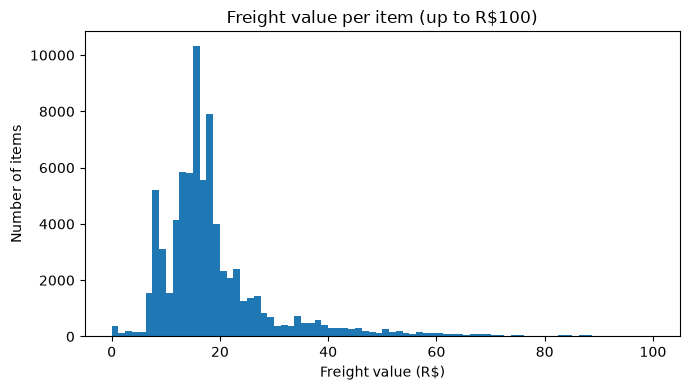

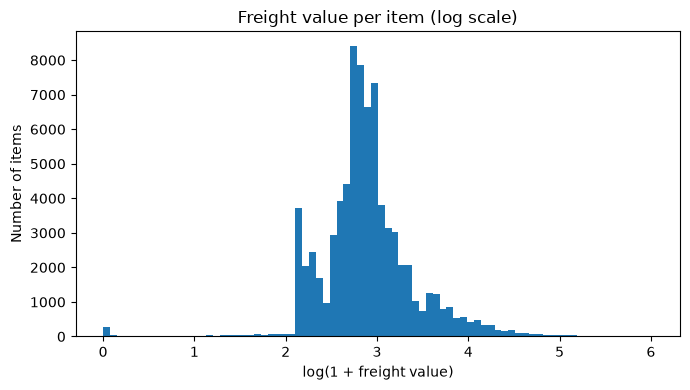

In [77]:
# Move the training freight values for plotting
freight_pd = train_df.select("freight_value").toPandas()

# Check how many values sit outside the first chart
over_100 = freight_pd[
    freight_pd["freight_value"] > 100
].shape[0]

print("Items above R$100:", over_100)


# Make the first histogram
plt.figure(figsize=(7, 4))

plt.hist(
    freight_pd["freight_value"],
    bins=80,
    range=(0, 100)
)

plt.title("Freight value per item (up to R$100)")
plt.xlabel("Freight value (R$)")
plt.ylabel("Number of items")

plt.tight_layout()
plt.show()


# Log transform the freight values
log_freight = np.log1p(freight_pd["freight_value"])

# Plot the transformed values
plt.figure(figsize=(7, 4))

plt.hist(
    log_freight,
    bins=80
)

plt.title("Freight value per item (log scale)")
plt.xlabel("log(1 + freight value)")
plt.ylabel("Number of items")

plt.tight_layout()
plt.show()

In [78]:
# Add temporary fields for exploration
explore_df = train_df.withColumn(
    "package_volume_cm3",
    F.col("product_length_cm") *
    F.col("product_height_cm") *
    F.col("product_width_cm")
)

explore_df = explore_df.withColumn(
    "is_intrastate",
    F.col("seller_state") == F.col("customer_state")
)


# Numeric fields to compare with freight
drivers = [
    "price",
    "product_weight_g",
    "package_volume_cm3",
    "order_item_count"
]

# Calculate each correlation
correlation_results = []

for driver in drivers:
    correlation = explore_df.stat.corr(
        "freight_value",
        driver
    )

    correlation_results.append({
        "feature": driver,
        "correlation_with_freight": round(correlation, 3)
    })

# Display the correlations
corr_rows = pd.DataFrame(correlation_results)

corr_rows

,feature,correlation_with_freight
0,price,0.407
1,product_weight_g,0.608
2,package_volume_cm3,0.579
3,order_item_count,-0.033


In [79]:
# Remove rows without a product weight
weight_df = explore_df.filter(
    F.col("product_weight_g").isNotNull()
)

# Put each item into a weight group
weight_df = weight_df.withColumn(
    "weight_band",
    F.when(F.col("product_weight_g") < 500, "1. under 0.5 kg")
     .when(F.col("product_weight_g") < 2000, "2. 0.5 to 2 kg")
     .when(F.col("product_weight_g") < 5000, "3. 2 to 5 kg")
     .when(F.col("product_weight_g") < 10000, "4. 5 to 10 kg")
     .otherwise("5. 10 kg and over")
)

# Compare freight across weight groups
weight_bands = weight_df.groupBy(
    "weight_band"
).agg(
    F.count("*").alias("items"),
    F.percentile_approx("freight_value", 0.5).alias("median_freight"),
    F.mean("freight_value").alias("mean_freight")
)

# Round the freight values
weight_bands = weight_bands.withColumn(
    "median_freight",
    F.round("median_freight", 2)
)

weight_bands = weight_bands.withColumn(
    "mean_freight",
    F.round("mean_freight", 2)
)

# Keep bands in order
weight_bands = weight_bands.orderBy("weight_band")

weight_bands.toPandas()

,weight_band,items,median_freight,mean_freight
0,1. under 0.5 kg,30765,15.10,15.15
1,2. 0.5 to 2 kg,28830,16.32,17.78
2,3. 2 to 5 kg,8064,19.94,22.63
3,4. 5 to 10 kg,6009,24.45,30.50
4,5. 10 kg and over,3680,43.16,54.45


In [80]:
# Group by whether the order stays in the same state
state_freight = explore_df.groupBy(
    "is_intrastate"
).agg(
    F.count("*").alias("items"),
    F.percentile_approx("freight_value", 0.5).alias("median_freight"),
    F.mean("freight_value").alias("mean_freight")
)

# Round the freight values
state_freight = state_freight.withColumn(
    "median_freight",
    F.round("median_freight", 2)
)

state_freight = state_freight.withColumn(
    "mean_freight",
    F.round("mean_freight", 2)
)

# Show comparison
state_freight.toPandas()

,is_intrastate,items,median_freight,mean_freight
0,True,28081,12.03,13.46
1,False,49282,18.24,23.68


### Findings and implications for modelling

**Distribution of freight**

We can see from the above charts that `freight_value` is clearly right-skewed, with a skewness of 5.73. Furthermore, we can also see that the median freight charge is R$16.26, while the mean is higher at R$19.97 due to the small number of very large freight values.

Additionally, we can also see that half of the training records sit between R$13.07 and R$21.15. On one hand, while the upper end of freight vlaues reaches R$409.68, we also can see that there are only 457 items, which accounts for ~0.6% of the training data, which sit above R$100.

Due to this, it is much easier for us to instead use the log-transformed histogram to identify visible peaks around some freight values, which suggests certain charges occur quite often rather than freight being spread smoothly across all possible values.

**Unusual freight values**

Another fact that becomes evident from our charts is that there are 257 items with a freight value of zero, which is around 0.3% of the training data. While these could arguably represent free shipping or promotional orders, it is also possible that they are indicative of missing or incorrect values.

Furthermore, there are also a small number of very high freight charges. While unusual, these values are kept due to the fact that we have no clear indication that they are errors, and it is useful for us to see how our model manages these really high, and really low values.

**Relationships with possible predictors**

We can see from our analysis that product weight has the strongest Pearson correlation with freight at 0.608. Package volume is also fairly strongly related at 0.579, followed by product price at 0.407.

On the other hand, we can see that `order_item_count` has almost no linear relationship with freight, with a correlation of -0.033. While evident of the lack of a *linear* relationship, we should note that this does not necessarily mean it has no value for prediction, and as such, we still want to consider it later when our model features are tested.

We can see that the weight bands also show that the effect of weight is not completely linear. Median freight only increases from R$15.10 for items under 0.5 kg to R$16.32 for items between 0.5 and 2 kg. This increase becomes much larger for heavier products, with median freight reaching R$43.16 for products weighing 10 kg or more.

Finally, we can see that location appears important as well. Interstate items have a median freight charge of R$18.24, while intrastate orders have a median of R$12.03.

**What this means for modelling**

The patterns we've discussed do suggest that some of the relationships with freight are not a straightforward linear relationship. As such, tree-based models are therefore useful candidates because they are arguably quite good at capturing non-linear patterns and interactions between features. However, a linear model is still included as a simpler baseline in our analysis.

Given that the target has a long upper tail, we want to compare model performance using both RMSE and MAE. RMSE gives more weight to the larger prediction errors, which is useful for seeing how the model handles expensive freight values, while MAE gives us a better sense of the typical error across most orders. Also, a log-transformed target is also tested to see whether reducing the skew improves prediction.

Overally, this exploration gives us a clear starting point for our model inputs. Most importantly, product weight, package dimensions, price and seller/customer location all show some relationship with freight, so these are carried forward into the feature engineering and model comparison steps.

---

## Part A: Machine learning pipeline

### 1. ML task selection

**Selected task: Our selected task is regression. Specifically for prediciting `freight_value` for each order item.**

#### Why regression is appropriate

Since `freight_value` is a continuous numeric value, regression is therefore the most direct fit for our problem. We can also see from our earlier interrogation that every row in the modelling dataset has a freight value, and in our training data it ranges from R$0 to R$409.68, with a mean of R$19.97 and a standard deviation of R$15.85. Furthermore, we note that there is also enough variation in the target for our model to learn actual patterns rather than simply predicting roughly the same value repeatedly for every item.

The available features also make sense for our particular type of prediction due to the fact that our earlier exploration showed that several of our available fields had a relationship with freight, particularly weight, package size and whether the item is shipped across state lines. We should also note that since some of these are numeric while others are categorical, the categorical fields need to be encoded before they can be used by our models. We want to specifically handle this as part of the feature pipeline in Section 2.

This also follows on naturally from our freight analysis in Assessment 1, which looked at historical freight charges and compared patterns across shipping lanes. Here on the other hand, our aim, while tangential, is slightly different. Here, we want to estimate what freight would normally be expected for an individual item based on its characteristics.

We then want to be able to leverage that prediction later on in Part B when new records arrive through Kafka. Each streamed item receives a predicted freight value, which we can then compare with the actual amount charged. Large differences could then be used to identify orders or shipping routes that may be worth looking at more closely.

Another reason this task is practical is that the prediction can be made at the time the order is placed. That is to say that all of the model inputs are already known at that point. Our model does not use information that only becomes available later, such as the actual delivery date, delivery duration or customer review. This makes prediction setup consistent with the near real-time scoring we plan to use in Part B.

#### Why other ML tasks were not chosen

**Classification**

Classification would require us to convert freight into categories, such as high or low freight. There is no obvious natural boundary for this, so a threshold would have to be chosen manually and would remove information from the original continuous value.

We note that our initial proposal originally considered a late-delivery flag as a possible classification target. While that would be a valid machine learning problem, it only focuses on delivery performance rather than the freight pricing question that we want to carry over from Assessment 1.

**Clustering**

Clustering is more useful when there is no target column and the aim is to find groups or patterns within the data. In our particular case, `freight_value` is already available as the outcome of interest. Producing cluster labels would therefore not directly answer the question being investigated.

**Other regression targets**

Delivery time could also be treated as a regression problem, for example by predicting the number of days between purchase and delivery. However, this again would shift our focus away from freight pricing. It also relies on information about delivery that is only known after the order has been completed.

---

### 2. Feature engineering

We want to keep the feature preparation and the model are together in one Spark ML `Pipeline` so that when the pipeline is fitted, any values that have to be learned from the data, such as medians, category mappings and scaling values, are learned from the training subset only.

The fitted `PipelineModel` can then be saved and reused in Part B. The streaming records therefore can go through the same preparation steps as the data used during training, rather than recreating those steps separately.

We note that the same feature preparation is also used for each of the candidate models in Section 3. This keeps our comparison fair, because the models are all trained from the same prepared inputs.

#### Features included

| Feature | Type | Source | Reason for inclusion |
|---|---|---|---|
| `price` | Numeric | Source column | Shows a moderate, linear relationship with freight (correlation score = 0.407) |
| `product_weight_g` | Numeric | Source column | Has the strongest linear relationship with freight (correlation score = 0.608) |
| `package_volume_cm3` | Numeric | Length × height × width | Package volume was also fairly strongly related to freight, (correlation score = 0.579). That is to say that larger parcels can cost more even when weight is similar |
| `distance_km` | Numeric | Calculated from seller and customer coordinates | Our earlier analysis shows clear differences between intrastate and interstate freight. Distance gives us a more detailed measure of how far the shipment travels |
| `is_intrastate` | Binary | Seller state compared with customer state | Distinguishes between shipments that stay within one state and those that cross a state border |
| `seller_state`, `customer_state` | Categorical | Source columns | Allows the model to pick up regional differences that may not be explained by distance alone |
| `product_category_name_english` | Categorical | Source column | Different types of products may have different packaging or handling requirements |
| `order_item_count` | Numeric | Number of items in the order | Its linear correlation with freight was almost zero at -0.033, but it may still be useful to us when combined with other features given that freight is recorded at an item level within an order |
| `purchase_month` | Numeric | Extracted from `order_purchase_timestamp` | Included to allow our model to pick up changes in freight across different times of the year. We note that in assessment 1, we saw that freight levels changed over time |

#### Columns excluded

| Column | Reason for exclusion |
|---|---|
| `order_id`, `order_item_id` | These are simply identifiers rather than meaningful characteristics of the shipment. Including them would give our model values it could simply memorise without learning any useful patterns |
| `order_purchase_timestamp` | We note that the full timestamp is not used as a model feature. We only want month is extracted from it, while the original timestamp is still kept for the streaming work in Part B |
| Seller and customer coordinates | The coordinates are used to calculate `distance_km`, but are not passed directly to the model. Importnatly, state and distance already capture the main geographic effect |
| Package length, height and width | These are combined into `package_volume_cm3` rather than being used individually, which avoids giving our model closely related versions of the same package-size information |
| Shipping lane | A combined seller-state to customer-state field would create many categories, including a number with relatively few records. Seller state, customer state, distance and `is_intrastate` already represent this information in a more meaningful way |
| Customer and seller postcode prefixes | These have very high cardinality, with ~15,000 possible values. Many prefixes have only a small number of examples, so they are unlikely to generalise well |
| Freight per kg, freight-to-price ratio | Both use `freight_value` in their calculation. Since freight is the target, including either would leak the answer into the model |
| Payments and reviews data | Reviews are only available after delivery. Payment totals also include the freight amount being predicted, so neither would be available as a clean input at the point of prediction |

#### Pipeline stages

| Stage | Transformer | What it does | Why we need it |
|---|---|---|---|
| 1 | `SQLTransformer` | Creates `distance_km`, `package_volume_cm3`, `is_intrastate` and `purchase_month`, and also converts our required numeric fields to doubles | Keeping these calculations inside the pipeline means that in Part B, we can send the original input fields and let the saved model perform the same transformations used during training. `distance_km` uses the haversine calculation between the seller and customer postcode-prefix coordinates, so it is still an approximate straight-line distance |
| 2 | `Imputer` | Replaces missing weight, volume and distance values using the median learned from the training data | Only a small number of rows are missing these fields, but streaming records cannot just be discarded. Median values give us a consistent replacement and are less affected by the large values in these skewed features |
| 3 | `StringIndexer` | Converts seller state, customer state and product category into numeric category indices | Since the Spark ML estimators need numeric inputs, `handleInvalid="keep"` can give any missing or previously unseen categories their own index instead of causing the pipeline to fail |
| 4 | `OneHotEncoder` | Converts the category indices into binary indicator features | This stops us from treating an index such as category 3 as being numerically larger than category 2. We can also handle unknown categories without stopping the stream |
| 5 | `VectorAssembler` | Collects all model inputs into one feature vector | Spark ML estimators expect the predictors to be supplied in a single vector column |
| 6 | `StandardScaler` | Scales the assembled features using their standard deviations, with `withMean=False` | We note that the inputs use very different units and ranges, which matters for our regularised linear model |

We note that `purchase_month` is kept as a numeric value from 1 to 12. This works more naturally for the tree models, which can split months into different groups where useful. However, the linear model can only treat it as a straight numeric trend, which is a limitation of the baseline model rather than the overall pipeline.

In [81]:
# Stage 1: create the derived features
derive_features = SQLTransformer(
    statement="""
        SELECT *,
            CAST(product_weight_g AS DOUBLE) AS weight_g,

            CAST(product_length_cm AS DOUBLE)
                * CAST(product_height_cm AS DOUBLE)
                * CAST(product_width_cm AS DOUBLE)
                AS package_volume_cm3,

            6371.0 * 2 * ASIN(
                SQRT(
                    POWER(
                        SIN(RADIANS(customer_lat - seller_lat) / 2),
                        2
                    )
                    +
                    COS(RADIANS(seller_lat))
                    * COS(RADIANS(customer_lat))
                    * POWER(
                        SIN(RADIANS(customer_lng - seller_lng) / 2),
                        2
                    )
                )
            ) AS distance_km,

            CASE
                WHEN seller_state = customer_state THEN 1.0
                ELSE 0.0
            END AS is_intrastate,

            CAST(MONTH(order_purchase_timestamp) AS DOUBLE)
                AS purchase_month

        FROM __THIS__
    """
)


# Stage 2: fill missing numeric values
imputer_inputs = [
    "weight_g",
    "package_volume_cm3",
    "distance_km"
]

imputer_outputs = [
    "weight_g_filled",
    "package_volume_cm3_filled",
    "distance_km_filled"
]

imputer = Imputer(
    strategy="median",
    inputCols=imputer_inputs,
    outputCols=imputer_outputs
)


# Stage 3: index the categorical fields
categorical_cols = [
    "seller_state",
    "customer_state",
    "product_category_name_english"
]

index_cols = []

for column in categorical_cols:
    index_cols.append(column + "_idx")

indexer = StringIndexer(
    inputCols=categorical_cols,
    outputCols=index_cols,
    handleInvalid="keep"
)


# Stage 4: one-hot encode the categories
encoded_cols = []

for column in categorical_cols:
    encoded_cols.append(column + "_ohe")

encoder = OneHotEncoder(
    inputCols=index_cols,
    outputCols=encoded_cols,
    handleInvalid="keep"
)


# Stage 5: put the model inputs into one vector
numeric_features = [
    "price",
    "weight_g_filled",
    "package_volume_cm3_filled",
    "distance_km_filled",
    "is_intrastate",
    "order_item_count",
    "purchase_month"
]

all_features = numeric_features + encoded_cols

assembler = VectorAssembler(
    inputCols=all_features,
    outputCol="features_unscaled"
)


# Stage 6: scale the features
scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features",
    withMean=False,
    withStd=True
)


# Keep the feature stages together
feature_stages = [
    derive_features,
    imputer,
    indexer,
    encoder,
    assembler,
    scaler
]

print("Feature stages defined:", len(feature_stages))

Feature stages defined: 6


In [82]:
# Fit the feature preparation on the training data
feature_pipeline = Pipeline(stages=feature_stages)

feature_model = feature_pipeline.fit(train_df)

# Apply the fitted preparation steps
train_features = feature_model.transform(train_df)


# Check the medians learned by the imputer
print("Medians learned for filling gaps:")

imputer_model = feature_model.stages[1]
imputer_model.surrogateDF.show()


# Check how many categories were learned
print("Categories learned:")

indexer_model = feature_model.stages[2]

for i in range(len(categorical_cols)):
    column = categorical_cols[i]
    labels = indexer_model.labelsArray[i]

    print(column + ":", len(labels), "categories")


# Check the size of the final feature vector
first_row = train_features.select("features").first()
feature_length = first_row["features"].size

print("\nFeature vector length:", feature_length)


# Check for nulls after the preparation steps
print("\nMissing values after preparation:")

null_checks = []

for column in numeric_features:
    null_checks.append(
        F.sum(
            F.col(column).isNull().cast("int")
        ).alias(column)
    )

train_features.select(null_checks).show()


# Show a few of the derived values
train_features.select(
    "freight_value",
    "distance_km_filled",
    "package_volume_cm3_filled",
    "is_intrastate",
    "purchase_month"
).show(5)

Medians learned for filling gaps:
+--------+------------------+------------------+
|weight_g|package_volume_cm3|       distance_km|
+--------+------------------+------------------+
|   700.0|            6480.0|431.13579837449134|
+--------+------------------+------------------+

Categories learned:
seller_state: 22 categories
customer_state: 27 categories
product_category_name_english: 73 categories

Feature vector length: 132

Missing values after preparation:
+-----+---------------+-------------------------+------------------+-------------+----------------+--------------+
|price|weight_g_filled|package_volume_cm3_filled|distance_km_filled|is_intrastate|order_item_count|purchase_month|
+-----+---------------+-------------------------+------------------+-------------+----------------+--------------+
|    0|              0|                        0|                 0|            0|               0|             0|
+-----+---------------+-------------------------+------------------+------

---

### 3. Model comparison and evaluation

#### Evaluation design

It is important for us to keep our streaming subset completely separate ahead of our Part B analysis. This is because we want to ensure that all model development is done using the training subset only.

Before we get to that, we want to first consider only the orders in our training subset (i.e. `train_df`), and we want to again split it into three groups:

- **Fitting set (60%)** for training each candidate model
- **Validation set (20%)** for comparing models and choosing hyperparameters
- **Test set (20%)** for the final evaluation of the selected model

Here, the split is done by `order_id`, just like we did earlier for the train/stream split. This helps us to ensure that every item from the same order is in the same group and thus avoids leakage between the fitting, validation and test data.

Next, the validation set is used to help us with deciding which model and parameter settings perform best overall. Given that these decisions are based on validation results, the validation score can end up looking slightly better than the model's true performance on unseen data. As such, the we there leave the test set untouched until the model has been selected, thereby giving us a cleaner final estimate of how well it generalises.

We want to use a single validation split instead of k-fold cross-validation. This is due to the fact that cross-validation would require each model configuration to be trained several times, which would be fairly expensive for the random forest and gradient-boosted tree models on our four-core local machine. With approximately 15,000 items in both the validation and test sets, the single split should still give us enough data for a useful comparison.

#### Evaluation metrics

We note that any and all model errors are reported on the original freight scale in Brazilian Reais (R$).

- **RMSE** is used as our main metric for choosing between models. We should note however that it gives extra weight to larger prediction errors, which matters for us specficially in our Part B use case due to the fact that a very large prediction error could make a normal freight charge look unusually high or low and thus create a false signal.
- **MAE** shows us the average absolute prediction error in reais therefore helps us to interpret the typical error on an individual item more easily. This is especially useful for us because most freight values sit well below the extreme upper tail.
- **R²** shows us how much of the variation in `freight_value` is explained by each model, which gives us another way to compare performance across candidates.

#### Candidate models

We note that for our analysis, each candidate is trained using the full pipeline, followed by the estimator itself. As such, the feature engineering stays the same for every model.

1. **Linear regression** is used as our baseline model. We want to include a small ridge penalty in order to make the coefficients more stable, particularly due to the fact that the one-hot encoded categorical features create a fairly wide feature vector.
2. **Random forest regression** helps us to combine predictions from many decision trees trained on different samples of rows and features. This allows it to capture non-linear patterns without relying on one individual tree.
3. **Gradient-boosted tree regression** builds trees one after another, with each new tree focusing on errors left by the earlier trees.

We note that the random forest and gradient-boosted tree models are tuned using the validation set. Finally, after our best model and settings are chosen, that final configuration is trained again using the full training subset before it is saved for use later in our analysis.

In [83]:
# Get the unique training orders
train_order_ids = train_df.select("order_id").distinct()

# Split the orders into fit, validation and test groups
fit_orders, val_orders, test_orders = train_order_ids.randomSplit(
    [0.6, 0.2, 0.2],
    seed=SEED
)

# Join the order groups back to item-level data
fit_df = train_df.join(
    fit_orders,
    on="order_id",
    how="inner"
)

val_df = train_df.join(
    val_orders,
    on="order_id",
    how="inner"
)

test_df = train_df.join(
    test_orders,
    on="order_id",
    how="inner"
)

# Cache the three subsets
fit_df.cache()
val_df.cache()
test_df.cache()

# Count the rows in each split
fit_count = fit_df.count()
val_count = val_df.count()
test_count = test_df.count()

total = fit_count + val_count + test_count

# Display final split
print("Fitting set:   ", f"{fit_count:,}", "items",
      f"({fit_count / total * 100:.1f}%)")

print("Validation set:", f"{val_count:,}", "items",
      f"({val_count / total * 100:.1f}%)")

print("Test set:      ", f"{test_count:,}", "items",
      f"({test_count / total * 100:.1f}%)")

print("Total:         ", f"{total:,}", "(expected 77,363)")

Fitting set:    46,583 items (60.2%)
Validation set: 15,434 items (20.0%)
Test set:       15,346 items (19.8%)
Total:          77,363 (expected 77,363)


In [84]:
# Evaluate set of model predictions
def evaluate(predictions, label_col="freight_value", prediction_col="prediction"):
    results = {}

    # Check each regression metric
    metrics = ["rmse", "mae", "r2"]

    for metric in metrics:
        evaluator = RegressionEvaluator(
            labelCol=label_col,
            predictionCol=prediction_col,
            metricName=metric
        )

        score = evaluator.evaluate(predictions)
        results[metric] = round(score, 3)

    return results

In [85]:
# Store results from each model
model_results = []


# Set up the linear regression baseline
lr = LinearRegression(
    featuresCol="features",
    labelCol="freight_value",
    regParam=0.01,
    elasticNetParam=0.0
)

# Add the model after feature preparation
lr_pipeline = Pipeline(
    stages=feature_stages + [lr]
)


# Fit the model and record training time
start_time = time.time()

lr_model = lr_pipeline.fit(fit_df)

lr_train_time = time.time() - start_time


# Make predictions
lr_val_preds = lr_model.transform(val_df)

# Score validation and fitting data
lr_val = evaluate(lr_val_preds)

lr_fit_preds = lr_model.transform(fit_df)
lr_fit = evaluate(lr_fit_preds)


# Save the results
lr_result = {
    "model": "Linear regression",
    "settings": "regParam=0.01",
    "val_rmse": lr_val["rmse"],
    "val_mae": lr_val["mae"],
    "val_r2": lr_val["r2"],
    "fit_rmse": lr_fit["rmse"],
    "train_secs": round(lr_train_time, 1)
}

model_results.append(lr_result)


# Check whether the model predicted any negative freight values
negative_predictions = lr_val_preds.filter(
    F.col("prediction") < 0
).count()

print("Negative predictions on validation set:", negative_predictions)

# Show the results
pd.DataFrame(model_results)

Negative predictions on validation set: 0


,model,settings,val_rmse,val_mae,val_r2,fit_rmse,train_secs
0,Linear regression,regParam=0.01,9.796,5.095,0.613,9.711,4.3


**Baseline results**

We can see from our results above that the linear regression explains 61.3% of the variation in freight on the validation set, with an R² of 0.613. Its RMSE is R$9.80 and its MAE is R$5.10.

However, we note that when compared with the median freight value of R$16.26, an average error of around R$5 is still fairly large. Furthermore, the gap between RMSE and MAE also suggests that the model is making a small number of much larger errors, most likely on the more expensive freight values in the upper tail.

We can see that the fitting RMSE is R$9.71, which is very close to the validation RMSE of R$9.80. From this, it would suggest to us that the model is not overfitting. Rather, the issue we can see here is that this model is likely too simple for some of the patterns in the data. This is consistent with our earlier analysis, which showed that freight does not increase in a smooth straight line with features such as weight, and as such a linear model is unlikely to capture all of that behaviour well.

One note we should call out is that there were no negative predictions on the validation set, so the model is at least producing plausible freight values.

While not a good fit overall, these results still provide us with a useful baseline to compare the tree-based models again, which should be better suited to the non-linear patterns and feature interactions in our data.

#### Tuning approach

Now that we have established a baseline with the linear approach, we now want to look to the random forest and gradient-boosted tree models. For these models, we first need to tune them by testing a small number of hyperparameter combinations. Each version is fitted using the fitting set we extracted earlier and is then scored on the validation set.

Importnatly, we note that Spark's built-in `TrainValidationSplit` is not used here due to the fact that it performs its own random row-level split, which we do not want as it could place different items from the same order into both training and validation data. Since we have already created an order-level validation set, the models can instead tested manually against that fixed split.

**Random forest**

Turning first to teh random forest model, we want to test four different combinations, which we can do using:

- `numTrees`: 50 and 100
- `maxDepth`: 8 and 12

We note that increasing the number of trees usually makes the final prediction more stable because it averages across more individual trees. This small improvement tends to get even smaller as more trees are added, while training time on the other hand continues to increase.

We also want to pay close attention to tree depth, which plays a key role is determining the level of detail that each tree can learn. On one hand, have deeper trees can allow for more complicated patterns and interactions to be learned, including the non-linear changes in freight seen during the earlier exploration. However, the main trade-off here is that very deep trees can start fitting noise in the training data, which leads to poor performance during validation.

**Gradient-boosted trees**

For the gradient-boosted trees, we again want to test four different combinations, this time using:

- `maxIter`: 50 and 100
- `maxDepth`: 4 and 6
- `stepSize`: 0.1

We note that boosting works very differently from random forest in that the trees are added one at a time. This means that each new tree tries to improve the errors left by the trees already fitted, and as a result, have more iterations therefore give the model more chances to improve. However, similar to the issues with our random forest design, having too many can also lead to overfitting.

Additionally, we should note that the boosted trees are kept shallower than the random forest trees by design. Since each new tree is only correcting the remaining errors, selecting depths of 4 and 6 still allow useful interactions between features without making each individual tree overly complex.

Importantly, these settings allows us to also test whether giving the models more capacity than Spark's defaults improves the results. Spark defaults to 20 trees for random forest, while gradient-boosted trees use 20 iterations and a maximum depth of 5 by default.

Furthermore, the grids are intentionally kept small. We note that there are only four settings for each tree model due to the fact that the gradient-boosted versions take several minutes to fit on the four-core local machine. 

Finally, as noted in earlier analysis, a seed of 42 is used for the tree models so the results can be reproduced when the notebook is rerun on the same data.

In [86]:
# Remove old random forest results in case this cell is rerun
clean_results = []

for result in model_results:
    if result["model"] != "Random forest":
        clean_results.append(result)

model_results = clean_results


# Random forest settings to test
rf_grid = [
    (50, 8),
    (50, 12),
    (100, 8),
    (100, 12)
]

best_rf_model = None
best_rf_rmse = float("inf")
best_rf_settings = None


# Train and score each combination
for num_trees, depth in rf_grid:

    rf = RandomForestRegressor(
        featuresCol="features",
        labelCol="freight_value",
        numTrees=num_trees,
        maxDepth=depth,
        seed=SEED
    )

    rf_pipeline = Pipeline(
        stages=feature_stages + [rf]
    )

    # Record how long training takes
    start_time = time.time()

    rf_model = rf_pipeline.fit(fit_df)

    train_time = time.time() - start_time


    # Score fitting and validation data
    val_predictions = rf_model.transform(val_df)
    fit_predictions = rf_model.transform(fit_df)

    val_scores = evaluate(val_predictions)
    fit_scores = evaluate(fit_predictions)

    settings = (
        "numTrees=" + str(num_trees) +
        ", maxDepth=" + str(depth)
    )


    # Save result
    result = {
        "model": "Random forest",
        "settings": settings,
        "val_rmse": val_scores["rmse"],
        "val_mae": val_scores["mae"],
        "val_r2": val_scores["r2"],
        "fit_rmse": fit_scores["rmse"],
        "train_secs": round(train_time, 1)
    }

    model_results.append(result)

    print(
        settings,
        "- validation RMSE:",
        val_scores["rmse"],
        "- training time:",
        round(train_time, 0),
        "seconds"
    )


    # Keep track of the best random forest
    if val_scores["rmse"] < best_rf_rmse:
        best_rf_rmse = val_scores["rmse"]
        best_rf_model = rf_model
        best_rf_settings = settings


# Show the best setting and all results so far
print("\nBest random forest:", best_rf_settings)

pd.DataFrame(model_results)

numTrees=50, maxDepth=8 - validation RMSE: 9.162 - training time: 22.0 seconds


numTrees=50, maxDepth=12 - validation RMSE: 8.782 - training time: 62.0 seconds


numTrees=100, maxDepth=8 - validation RMSE: 9.159 - training time: 46.0 seconds


numTrees=100, maxDepth=12 - validation RMSE: 8.773 - training time: 115.0 seconds

Best random forest: numTrees=100, maxDepth=12


,model,settings,val_rmse,val_mae,val_r2,fit_rmse,train_secs
0,Linear regression,regParam=0.01,9.796,5.095,0.613,9.711,4.3
1,Random forest,"numTrees=50, maxDepth=8",9.162,4.358,0.661,8.102,22.0
2,Random forest,"numTrees=50, maxDepth=12",8.782,4.074,0.689,6.500,62.0
3,Random forest,"numTrees=100, maxDepth=8",9.159,4.354,0.662,8.077,46.1
4,Random forest,"numTrees=100, maxDepth=12",8.773,4.049,0.689,6.471,115.1


In [87]:
# Remove any earlier gradient-boosted tree results, so rerunning this cell doesn't duplicate rows
model_results = [r for r in model_results if r["model"] != "Gradient-boosted trees"]

# Gradient-boosted trees: every combination of iterations and maximum depth
gbt_grid = [(50, 4), (50, 6), (100, 4), (100, 6)]
best_gbt_model, best_gbt_rmse, best_gbt_settings = None, float("inf"), None

for iterations, depth in gbt_grid:
    gbt = GBTRegressor(
        featuresCol="features",
        labelCol="freight_value",
        maxIter=iterations,
        maxDepth=depth,
        stepSize=0.1,
        seed=SEED
    )
    pipeline = Pipeline(stages=feature_stages + [gbt])

    start = time.time()
    model = pipeline.fit(fit_df)
    train_time = time.time() - start

    val = evaluate(model.transform(val_df))
    fit = evaluate(model.transform(fit_df))
    settings = f"maxIter={iterations}, maxDepth={depth}"

    model_results.append({
        "model": "Gradient-boosted trees",
        "settings": settings,
        "val_rmse": val["rmse"],
        "val_mae": val["mae"],
        "val_r2": val["r2"],
        "fit_rmse": fit["rmse"],
        "train_secs": round(train_time, 1)
    })
    print(f"{settings}: validation RMSE {val['rmse']}, trained in {train_time:.0f}s")

    # Keep the best configuration so it doesn't need retraining later
    if val["rmse"] < best_gbt_rmse:
        best_gbt_model, best_gbt_rmse, best_gbt_settings = model, val["rmse"], settings

print("\nBest gradient-boosted trees:", best_gbt_settings)
pd.DataFrame(model_results)

maxIter=50, maxDepth=4: validation RMSE 9.059, trained in 37s


maxIter=50, maxDepth=6: validation RMSE 9.233, trained in 53s


maxIter=100, maxDepth=4: validation RMSE 9.034, trained in 74s


maxIter=100, maxDepth=6: validation RMSE 9.145, trained in 105s

Best gradient-boosted trees: maxIter=100, maxDepth=4


,model,settings,val_rmse,val_mae,val_r2,fit_rmse,train_secs
0,Linear regression,regParam=0.01,9.796,5.095,0.613,9.711,4.3
1,Random forest,"numTrees=50, maxDepth=8",9.162,4.358,0.661,8.102,22.0
2,Random forest,"numTrees=50, maxDepth=12",8.782,4.074,0.689,6.500,62.0
3,Random forest,"numTrees=100, maxDepth=8",9.159,4.354,0.662,8.077,46.1
4,Random forest,"numTrees=100, maxDepth=12",8.773,4.049,0.689,6.471,115.1
5,Gradient-boosted trees,"maxIter=50, maxDepth=4",9.059,4.235,0.669,7.997,37.5
6,Gradient-boosted trees,"maxIter=50, maxDepth=6",9.233,4.221,0.656,7.032,53.3
7,Gradient-boosted trees,"maxIter=100, maxDepth=4",9.034,4.134,0.671,7.415,73.8
8,Gradient-boosted trees,"maxIter=100, maxDepth=6",9.145,4.105,0.662,6.228,105.0


In [88]:
# Remove old results if cell is rerun
clean_results = []

for result in model_results:
    if result["model"] != "Random forest (log target)":
        clean_results.append(result)

model_results = clean_results


# Create a log version of freight for training
fit_df_log = fit_df.withColumn(
    "log_freight",
    F.log1p(F.col("freight_value"))
)


# Use the best random forest settings with the log target
rf_log = RandomForestRegressor(
    featuresCol="features",
    labelCol="log_freight",
    numTrees=100,
    maxDepth=12,
    seed=SEED
)


# Convert predictions back to the original freight scale
back_transform = SQLTransformer(
    statement="""
        SELECT *,
            EXP(prediction) - 1 AS prediction_reais
        FROM __THIS__
    """
)


# Build the full pipeline
rf_log_pipeline = Pipeline(
    stages=feature_stages + [rf_log, back_transform]
)


# Fit the log-target model
start_time = time.time()

rf_log_model = rf_log_pipeline.fit(fit_df_log)

train_time = time.time() - start_time


# Score validation predictions in reais
val_predictions = rf_log_model.transform(val_df)

val_scores = evaluate(
    val_predictions,
    prediction_col="prediction_reais"
)


# Score the fitting data as well
fit_predictions = rf_log_model.transform(fit_df)

fit_scores = evaluate(
    fit_predictions,
    prediction_col="prediction_reais"
)


# Save the result
result = {
    "model": "Random forest (log target)",
    "settings": "numTrees=100, maxDepth=12",
    "val_rmse": val_scores["rmse"],
    "val_mae": val_scores["mae"],
    "val_r2": val_scores["r2"],
    "fit_rmse": fit_scores["rmse"],
    "train_secs": round(train_time, 1)
}

model_results.append(result)

# Show all results
pd.DataFrame(model_results)

,model,settings,val_rmse,val_mae,val_r2,fit_rmse,train_secs
0,Linear regression,regParam=0.01,9.796,5.095,0.613,9.711,4.3
1,Random forest,"numTrees=50, maxDepth=8",9.162,4.358,0.661,8.102,22.0
2,Random forest,"numTrees=50, maxDepth=12",8.782,4.074,0.689,6.500,62.0
3,Random forest,"numTrees=100, maxDepth=8",9.159,4.354,0.662,8.077,46.1
4,Random forest,"numTrees=100, maxDepth=12",8.773,4.049,0.689,6.471,115.1
5,Gradient-boosted trees,"maxIter=50, maxDepth=4",9.059,4.235,0.669,7.997,37.5
6,Gradient-boosted trees,"maxIter=50, maxDepth=6",9.233,4.221,0.656,7.032,53.3
7,Gradient-boosted trees,"maxIter=100, maxDepth=4",9.034,4.134,0.671,7.415,73.8
8,Gradient-boosted trees,"maxIter=100, maxDepth=6",9.145,4.105,0.662,6.228,105.0
9,Random forest (log target),"numTrees=100, maxDepth=12",9.032,3.937,0.671,7.246,121.1


In [89]:
# Put all results into one table
comparison = pd.DataFrame(model_results)

# Compare fitting and validation RMSE
comparison["overfit_gap"] = (
    comparison["val_rmse"] - comparison["fit_rmse"]
).round(3)

# Sort using validation RMSE
comparison = comparison.sort_values(
    by="val_rmse",
    ascending=True
)

comparison = comparison.reset_index(drop=True)


# Rename columns for the final display
comparison = comparison.rename(columns={
    "model": "Model",
    "settings": "Settings",
    "val_rmse": "Validation RMSE",
    "val_mae": "Validation MAE",
    "val_r2": "Validation R²",
    "fit_rmse": "Fitting RMSE",
    "overfit_gap": "Overfitting gap",
    "train_secs": "Training time (s)"
})

comparison

,Model,Settings,Validation RMSE,Validation MAE,Validation R²,Fitting RMSE,Training time (s),Overfitting gap
0,Random forest,"numTrees=100, maxDepth=12",8.773,4.049,0.689,6.471,115.1,2.302
1,Random forest,"numTrees=50, maxDepth=12",8.782,4.074,0.689,6.500,62.0,2.282
2,Random forest (log target),"numTrees=100, maxDepth=12",9.032,3.937,0.671,7.246,121.1,1.786
3,Gradient-boosted trees,"maxIter=100, maxDepth=4",9.034,4.134,0.671,7.415,73.8,1.619
4,Gradient-boosted trees,"maxIter=50, maxDepth=4",9.059,4.235,0.669,7.997,37.5,1.062
5,Gradient-boosted trees,"maxIter=100, maxDepth=6",9.145,4.105,0.662,6.228,105.0,2.917
6,Random forest,"numTrees=100, maxDepth=8",9.159,4.354,0.662,8.077,46.1,1.082
7,Random forest,"numTrees=50, maxDepth=8",9.162,4.358,0.661,8.102,22.0,1.060
8,Gradient-boosted trees,"maxIter=50, maxDepth=6",9.233,4.221,0.656,7.032,53.3,2.201
9,Linear regression,regParam=0.01,9.796,5.095,0.613,9.711,4.3,0.085


In [90]:
# Show the selected random forest settings
print("Selected model: Random forest,", best_rf_settings)

# Score the selected model on validation data
val_predictions = best_rf_model.transform(val_df)
val_metrics = evaluate(val_predictions)

# Score it once on the untouched test data
test_predictions = best_rf_model.transform(test_df)
test_metrics = evaluate(test_predictions)

# Put both results into one table
final_scores = pd.DataFrame([
    {
        "set": "Validation",
        "rmse": val_metrics["rmse"],
        "mae": val_metrics["mae"],
        "r2": val_metrics["r2"]
    },
    {
        "set": "Test",
        "rmse": test_metrics["rmse"],
        "mae": test_metrics["mae"],
        "r2": test_metrics["r2"]
    }
])

final_scores

Selected model: Random forest, numTrees=100, maxDepth=12


,set,rmse,mae,r2
0,Validation,8.773,4.049,0.689
1,Test,9.761,4.186,0.656


In [91]:
# Get predictions for both sets
val_preds = best_rf_model.transform(val_df)
test_preds = best_rf_model.transform(test_df)

rows = []


# Compare the shape of each result set
for name, preds in [
    ("Validation", val_preds),
    ("Test", test_preds)
]:

    summary = preds.select(
        F.count("*").alias("items"),
        F.stddev("freight_value").alias("freight_std"),
        F.max("freight_value").alias("max_freight"),
        F.sum(
            (F.col("freight_value") > 100).cast("int")
        ).alias("items_over_100"),
        F.max(
            F.abs(
                F.col("prediction") - F.col("freight_value")
            )
        ).alias("largest_error")
    ).first()


    # Store the main statistics
    stats = {
        "set": name,
        "items": summary["items"],
        "freight_std": round(summary["freight_std"], 2),
        "max_freight": round(summary["max_freight"], 2),
        "items_over_100": summary["items_over_100"],
        "largest_error": round(summary["largest_error"], 2)
    }


    # Check performance without the high freight tail
    core_preds = preds.filter(
        F.col("freight_value") <= 100
    )

    core_scores = evaluate(core_preds)

    stats["rmse_up_to_100"] = core_scores["rmse"]
    stats["mae_up_to_100"] = core_scores["mae"]

    rows.append(stats)


# Display the comparison
set_comparison = pd.DataFrame(rows)

set_comparison

,set,items,freight_std,max_freight,items_over_100,largest_error,rmse_up_to_100,mae_up_to_100
0,Validation,15434,15.74,322.10,95,199.09,7.013,3.736
1,Test,15346,16.63,375.28,94,232.18,7.277,3.831


**Test set result**

From our above analysis, we can see that the selected random forest gives a test RMSE of R$9.76, compared with R$8.77 on the validation set. We note that this is ~11% higher. Conversely, the difference is much smaller for MAE, which increases from R$4.05 to R$4.19, while R² falls from 0.689 to 0.656.

These extra checks suggest that most of the RMSE difference we are seeing likely comes from the very high freight values rather than a general drop in accuracy. We note that the validation and test sets contain almost the same number of items above R$100, with 95 and 94 respectively, but the test set contains much more extreme charges, with a maximum freight value of R$375.28 compared with R$322.10 in validation, and the overall spread of freight values is also higher. Furthermore, we can see that the largest individual prediction error is R$232.18 in the test set, compared with R$199.09 in validation.

Additionally, when we limit the comparison to items with freight of R$100 or less, which covers more than 99% of the records, we can see that the RMSE difference falls from R$0.99 to only R$0.26, and also MAE differs by less than R$0.10. This suggests to us that the model's accuracy for more typical freight values carries over quite well to unseen orders, while performance on the small number of very expensive shipments is less consistent.

On one hand, we know that some difference between validation and test performance are to be expected due to the fact that the model and its settings were chosen using the validation results. The untouched test set is therefore the better estimate of how the model should perform on new data. As such, we have a final benchmark for Part B as $9.76 for RMSE, R$4.19 for MAE and 0.656 for R².

This is also important for us later when the predictions are used for monitoring purposes. More specifically, a large difference between predicted and actual freight on a very high-value shipment may partly reflect the model being less accurate in that sparse end of the data. We should therefore interpet those cases more carefully than a similar prediction error on a more typical shipment.

In [92]:
# Feature importance values from the selected random forest
rf_stage = best_rf_model.stages[-1]
importances = rf_stage.featureImportances.toArray()


# Feature names from the assembled vector metadata
sample = best_rf_model.transform(
    val_df.limit(1)
)

metadata = sample.schema["features_unscaled"].metadata
attrs = metadata["ml_attr"]["attrs"]

names = {}

for group in attrs.values():
    for item in group:
        index = item["idx"]
        name = item["name"]
        names[index] = name


# Match each vector position to its importance
importance_rows = []

for i in range(len(importances)):
    importance_rows.append({
        "column": names[i],
        "importance": importances[i]
    })

imp_df = pd.DataFrame(importance_rows)


# Map one-hot columns back to their original feature
def source_feature(column):
    for category in categorical_cols:
        if column.startswith(category + "_ohe"):
            return category

    return column


imp_df["feature"] = imp_df["column"].apply(source_feature)


# Add together importance from the same original feature
feature_importance = imp_df.groupby(
    "feature"
)["importance"].sum()

feature_importance = feature_importance.sort_values(
    ascending=False
).round(3).reset_index()


print("Importance by feature:")
display(feature_importance)


# Show the most important individual vector columns
top_columns = imp_df.sort_values(
    "importance",
    ascending=False
)

top_columns = top_columns.head(10)[
    ["column", "importance"]
].copy()

top_columns["importance"] = top_columns["importance"].round(3)
top_columns = top_columns.reset_index(drop=True)

print("Top 10 individual columns:")
display(top_columns)

Importance by feature:


,feature,importance
0,weight_g_filled,0.276
1,package_volume_cm3_filled,0.197
2,distance_km_filled,0.134
3,price,0.113
4,is_intrastate,0.089
5,customer_state,0.063
6,product_category_name_english,0.062
7,seller_state,0.033
8,purchase_month,0.020
9,order_item_count,0.012


Top 10 individual columns:


,column,importance
0,weight_g_filled,0.276
1,package_volume_cm3_filled,0.197
2,distance_km_filled,0.134
3,price,0.113
4,is_intrastate,0.089
5,customer_state_ohe_SP,0.022
6,purchase_month,0.020
7,seller_state_ohe_SP,0.013
8,order_item_count,0.012
9,product_category_name_english_ohe_office_furni...,0.008


**Feature importance**

We note that the random forest depends most on the physical characteristics of the shipment. More specifically, product weight has an importance of 0.276 and package volume 0.197, so together they account for almost half of the total feature importance.

Location is also a major part of the model. Distance has an importance of 0.134, followed by the intrastate flag at 0.089, customer state at 0.063 and seller state at 0.033. Combined, these geographic features contribute about 0.32. In particular, we can see that São Paulo appears among the ten most important individual one-hot columns for both seller and customer state, which lines up with our results from Assessment 1, where a large share of orders involved São Paulo.

Furthermore, price contributes 0.113, while product category and purchase month have smaller roles at 0.062 and 0.020 respectively.

Conversely, we can see that `order_item_count` has the lowest importance at 0.012. This aligns with our earlier exploration, where its direct relationship with freight was very weak. Despite this however, we still want to retain it in in the model due to the fact that it still does make a small contribution and removing it would mean repeating the model training and tuning for what would likely be very little ultimate benefit.

We note that these importance values need to still be read with some caution. That is to say that random forest importance is based on how much each feature improves tree splits, which can favour continuous variables due to the fact that they provide more possible split points. Categorical features on the other hand are spread across several one-hot encoded columns, and as such their importance can look smaller when viewed individually.

#### Model selection

**Selected model: random forest with 100 trees and a maximum depth of 12, predicting `freight_value` directly in reais**

We have selected the random forest model due to the fact that it gives the best validation RMSE, which is the main metric that we wnat to use for model choice. Its RMSE of R$8.773 is lower than the best gradient-boosted model at R$9.034, and is also much lower than the linear regression baseline at R$9.796. Furthermore, we can see that it also performs better on the other main measures when using the original freight target, with an MAE of R$4.049 and an R² of 0.689.

**Why it outperformed the alternatives on this dataset**

From our analysis, we can clearly see that linear regression is clearly the weakest of the three approaches. Its fitting and validation RMSE are almost the same, with a difference of only R$0.085, so it is evident that overfitting is not the issue there. Instead, it actually appears to underfit the data. In fact, oru exploration shows that freight does not change in a simple linear way, particularly across different weight ranges, and as such, a straight-line model cannot capture those patterns well.

When we turn to the random forest model, we can see that its performance does improve as the trees are allowed to become deeper. In fact, when we move from depth 8 to depth 12, we can see that it reduces the validation RMSE from R$9.159 to R$8.773 for both forest sizes. This suggests to us that there are useful interactions between the features that need more detailed tree splits, such as the effect of weight changing depending on distance or location.

We also considered gradient boosting, which we note does perform well, but we can see from the above tables that the deeper versions show more signs of overfitting. In particular, by increasing depth from 4 to 6, we see that we slightly improve in terms of MAE, from R$4.134 to R$4.105, but consequentially make RMSE worse by increasing it from R$9.034 to R$9.145. Furthermore, we can see that it also produces the largest gap between fitting and validation RMSE, at R$2.917. Due to the fact that boosting repeatedly focuses on the remaining prediction errors, we note that it may be putting too much attention on the small number of extreme freight values, like we noted in our discussion earlier. 

In fact, our earlier test-set checks showed that these high-value items are also the least stable part of the target. We note that the random forest model is, on the other hand, less affected by this because its final result is averaged across independently trained trees.

We also conducting some testing of the log-transformed target. We note that it produces the lowest MAE overall at R$3.937, but its RMSE of R$9.032 and R² of 0.671 are both worse than the selected random forest. Looking at the outputs, we can see that transforming the target reduces the influence of large freight values during training, which improves predictions for more typical items but on the flip side, it makes expensive shipments easier to underestimate. Since RMSE is the main selection metric and large errors are important for the Part B monitoring use case, the model trained directly on freight is preferred.

**100 trees rather than 50** 

We note that the difference between 50 and 100 trees is small. At depth 12, we can see that increasing the forest to 100 trees only improves RMSE by R$0.009 and MAE by R$0.025, while training time increases from 57.3 seconds to 104.5 seconds. Despite this increase in time, the 100-tree version is still selected because it performs slightly better on all three evaluation metrics, and model training happens offline rather than during streaming. Furthermore, since we have completed this analysis, we can be comfortable later that in the event when scoring speed becomes an issue for us in Part B, the 50-tree version would be a reasonable lower-cost alternative.

**Overfitting** 

We can see that there is some overfitting in our selected model. Its fitting RMSE is R$6.471 compared with R$8.773 on validation, a difference of R$2.302. However, we also see that the validation performance continued to improve as tree depth increased, and test MAE was only around 3% higher than validation MAE. This suggests to us that although the model fits the training data more closely, most of its accuracy still carries across to unseen orders.

**Implications for deployment**

To summarise, we see that the final test results give the best estimate of expected performance on new data: RMSE of R$9.76, MAE of R$4.19 and R² of 0.656. For Part B, this means that small differences between predicted and actual freight should not automatically be treated as unusual. Rather, an error of a few reais is normal for this model. Larger differences, especially on the more common lower-value shipments where the model is more reliable, are more useful to us as possible signals of unusual freight pricing.

---

### 4. Model persistence and verification

Now that we have selected the random forest configuration, using 100 trees with a maximum depth of 12, our next goal is to train it again using the full training subset before we can save it.

In our earlier model comparison, we only trained models on the fitting split, while we kept the validation and test sets separate for model selection and final evaluation. Now that our model choice is finished, we can now combine those three training splits again. This gives the final model with all 77,363 training items to learn from, giving us around 66% more data than the fitting split alone. We note that the separate streaming subset has still remained untouched.

#### Saving the full pipeline

Our saved model is the complete fitted `PipelineModel`, rather than just the random forest stage. This means that it contains all of the preparation and modelling steps in the same order:

1. `SQLTransformer` to create distance, package volume, the intrastate flag and purchase month
2. `Imputer` containing the medians learned from the training data
3. `StringIndexer` containing the category mappings learned during fitting
4. `OneHotEncoder`
5. `VectorAssembler`
6. `StandardScaler` containing the learned scaling values
7. the fitted random forest model

By keeping everything together, it means that the same transformations which we used during our training process can again be applied when new records arrive later in our analysis. As such, there is no need for us to recreate feature engineering separately in Part B or recalculate any of our learned preparation values.

#### Link to Part B

We note that since our streaming consumer that we will utilise in Part B is able to load the saved pipeline from `models/a2_model` and apply it to each micro-batch using `.transform()`, therefore nothing needs to be fitted again during streaming.

This also means our Part A pipeline defines what our Part B input needs to look like. More specifically, each incoming record must contain the raw columns expected by the pipeline, using the same names and compatible data types.

Our checks below reload the saved model and confirm that it produces the same predictions as the version currently in memory to confirm that we won't run into issues with Part B later. They also will allow us to record the raw input fields required by our pipeline so the Kafka producer and consumer schema can be kept consistent with the trained model.

In [93]:
# Set up the selected random forest again
final_rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="freight_value",
    numTrees=100,
    maxDepth=12,
    seed=SEED
)

# Add it to the same feature pipeline
final_pipeline = Pipeline(
    stages=feature_stages + [final_rf]
)


# Fit the final model on all training rows
start_time = time.time()

bestModel = final_pipeline.fit(train_df)

fit_time = time.time() - start_time
final_rows = train_df.count()

print(
    "Refitted on",
    f"{final_rows:,}",
    "items in",
    f"{fit_time:.0f}s"
)


# Save the complete fitted pipeline for Part B
bestModel.write() \
    .overwrite() \
    .save(MODEL_PATH)

print("Saved to:", MODEL_PATH)

Refitted on 77,363 items in 171s


Saved to: models/a2_model


In [94]:
# Size of the saved model folder
!du -sh {MODEL_PATH}

 10M	models/a2_model


In [95]:
# Load the saved pipeline back from disc
loaded_model = PipelineModel.load(MODEL_PATH)


# Check which stages were saved
print("Stages in the reloaded pipeline:")

stage_number = 1

for stage in loaded_model.stages:
    print(" ", stage_number, ".", type(stage).__name__)
    stage_number += 1


# Make a small sample without the target column
sample_input = test_df.drop("freight_value")

sample_input = sample_input.orderBy(
    "order_id",
    "order_item_id"
).limit(5)


# Get predictions from both versions of the model
reloaded_preds = loaded_model.transform(sample_input)
original_preds = bestModel.transform(sample_input)


# Check the prediction output and feature vector
prediction_type = reloaded_preds.schema["prediction"].dataType

first_features = reloaded_preds.select("features").first()
feature_length = first_features["features"].size

print("\nPrediction column type:", prediction_type)
print("Feature vector length:", feature_length)


# Compare predictions from the saved and in-memory models
reloaded_check = reloaded_preds.select(
    "order_id",
    "order_item_id",
    F.col("prediction").alias("reloaded")
)

original_check = original_preds.select(
    "order_id",
    "order_item_id",
    F.col("prediction").alias("original")
)

comparison_check = reloaded_check.join(
    original_check,
    on=["order_id", "order_item_id"],
    how="inner"
)

max_diff = comparison_check.select(
    F.max(
        F.abs(F.col("reloaded") - F.col("original"))
    )
).first()[0]

print(
    "Largest difference between reloaded and original predictions:",
    max_diff
)


# Raw columns needed by the saved pipeline
required_inputs = [
    "price",
    "order_item_count",
    "order_purchase_timestamp",
    "seller_state",
    "customer_state",
    "product_category_name_english",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "seller_lat",
    "seller_lng",
    "customer_lat",
    "customer_lng"
]


# Check that the saved streaming data contains them
stream_columns = spark.read.parquet(STREAM_PATH).columns

missing_from_stream = []

for column in required_inputs:
    if column not in stream_columns:
        missing_from_stream.append(column)

print("\nRequired raw inputs:", len(required_inputs))

if len(missing_from_stream) == 0:
    print("Missing from the stream file: none")
else:
    print("Missing from the stream file:", missing_from_stream)


# Show a few predictions from the reloaded model
reloaded_preds.select(
    "order_id",
    "order_item_id",
    "weight_g_filled",
    "distance_km_filled",
    F.round("prediction", 2).alias("predicted_freight")
).show(truncate=False)

Stages in the reloaded pipeline:
  1 . SQLTransformer
  2 . ImputerModel
  3 . StringIndexerModel
  4 . OneHotEncoderModel
  5 . VectorAssembler
  6 . StandardScalerModel
  7 . RandomForestRegressionModel

Prediction column type: DoubleType()
Feature vector length: 132
Largest difference between reloaded and original predictions: 0.0

Required raw inputs: 14
Missing from the stream file: none
+--------------------------------+-------------+---------------+------------------+-----------------+
|order_id                        |order_item_id|weight_g_filled|distance_km_filled|predicted_freight|
+--------------------------------+-------------+---------------+------------------+-----------------+
|00018f77f2f0320c557190d7a144bdd3|1            |30000.0        |585.5639365089672 |39.11            |
|0005f50442cb953dcd1d21e1fb923495|1            |850.0          |33.24946825936782 |10.05            |
|000aed2e25dbad2f9ddb70584c5a2ded|1            |468.0          |37.936705502519615|9.84       

**Verification results**

We can see that the model loaded from `models/a2_model` contains all seven fitted pipeline stages in the correct order, starting with the `SQLTransformer` and ending with the `RandomForestRegressionModel`, exactly as we were expecting.

In order for us to be able to check that the saved model still works properly, it was first applied to five sample items with `freight_value` removed. We note that this is closely aligned to how the model will be used in later on in Part B, where the pipeline receives the raw fields needed for prediction rather than using the target as an input.

We can also see that the output matches our original fitted pipeline. The prediction column is returned as a `DoubleType`, and the model uses a 132-element feature vector, which is the same size that we produced earlier in Section 2. Importantly, the largest difference between predictions from the saved model and the previous in-memory version was 0.0, ultimately showing that saving and reloading the pipeline did not change its behaviour.

Furthermore, the sample predictions also appear reasonable. For example, a 30 kg item travelling about 586 km is predicted at R$39.11, while a much lighter 468 g item travelling around 38 km is predicted at R$9.84.

**Input contract for Part B**

We note that the saved pipeline expects 14 raw input columns, and our check confirms that all of them are available in the streaming subset:

| Group | Columns |
|---|---|
| Order | `price`, `order_item_count`, `order_purchase_timestamp` |
| Location | `seller_state`, `customer_state`, `seller_lat`, `seller_lng`, `customer_lat`, `customer_lng` |
| Product | `product_category_name_english`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` |

The Kafka producer sends these fields in each JSON message, along with the order identifiers and the actual `freight_value`, and an added `event_timestamp` when the record is published. However, the actual freight value is not included as an input feature, even though we still retain it purely so that we can later compare it with the model prediction.

Also, the consumer uses an explicit schema with the same field names and compatible data types. `order_purchase_timestamp` in particular needs to be parsed as a timestamp because the saved pipeline uses it to create `purchase_month`.

Finally, we note that all of the other preparation is already stored in the fitted pipeline, including the derived features, imputation values, category mappings and scaling values. Part B therefore only needs us to load the saved model and apply `.transform()` to each micro-batch. Nothing is fitted again during streaming.

In [96]:
# Release the Part A data cached in memory
spark.catalog.clearCache()
print("Cached Part A data released")

Cached Part A data released


---

## Part B: Streaming, Kafka and reflection

### 1. Streaming data simulation and Kafka producer

As we have discussed earlier in our analysis, this Part B section is where we want to use Kafka to replay the held-out streaming data as if new order items were arriving over time. We know that this subset contains 32,826 items and we took specific care throughout earlier steps to ensure that this was kept completely separate from our model training process.

The standalone `producer.py` script reads the records from `data/stream_data.parquet` and sends them to the `events` Kafka topic in batches. Then our notebook is able to read from this topic, and apply the saved model and track the predictions as the records arrive.

There are some key design choices which we want to make as follows:

| Design choice | Setting | Reason |
|---|---|---|
| Batch size | 500 records (set with `--batch-size`) | With 32,826 items, the replay produces 66 batches and runs for about 5.5 minutes, which gives enough time for several aggregation windows |
| Interval | Exactly 5 seconds between batches | This keeps the arrival rate controlled and matches the requirement from our assessment brief |
| Message format | Each batch is one Kafka message holding a JSON array of records | We know from testing that one batch of 500 records is around 255 KB, which stays below Kafka's default 1 MB message limit |
| Replay order | Sorted by `order_purchase_timestamp` | This keeps the records in roughly the same order that the original purchases occurred |
| `event_timestamp` | The batch's publish time (UTC), added to every record | This gives our stream an arrival-time field that we can use later for windowing and watermarking |
| Topic partitions | 1 | We know that Kafka preserves ordering within a partition, so using one partition helps us to keep the producer's replay order |
| Integer columns | Converted to nullable integers before serialisation | This prevents missing integer fields from being turned into decimal values such as `850.0`, which would not match the integer types expected by the consumer |

Since we have already documented detailed commands and instructions in this project's README, we do not want to repeat those instructions here. Instead, we simply want to look at an excerpt from a full producer run so that we can log the record count and timestamp:

```
2026-10-06 01:07:36,523 | INFO | Topic: events | Batch size: 500 | Batches: 66 | Interval: 5s
2026-10-06 01:07:36,829 | INFO | Batch 1/66 | records: 500 | event_timestamp: 2026-10-05T14:07:36.614+00:00 | size: 254.6 KB | total sent: 500
2026-10-06 01:07:42,167 | INFO | Batch 2/66 | records: 500 | event_timestamp: 2026-10-05T14:07:41.836+00:00 | size: 254.8 KB | total sent: 1000
...
2026-10-06 01:13:08,580 | INFO | Batch 66/66 | records: 326 | event_timestamp: 2026-10-05T14:13:08.537+00:00 | size: 166.1 KB | total sent: 32826
2026-10-06 01:13:08,582 | INFO | Producer closed. Total records sent: 32826
```

### 2. Structured Streaming consumer

We note that the consumer uses Spark Structured Streaming to read the `events` Kafka topic continuously. 

**Reading from Kafka**

Firstly, we want to note that `startingOffsets` is set to `latest`, which means that only messages sent _after_ the consumer starts are processed, and any messages left in the topic from earlier test runs are ignored.

On one hand, while this is closer to how a live consumer would behave, it also means that the consumer needs to be running before the producer starts sending records.

**Parsing the Kafka messages**

Each Kafka message contains a JSON array rather than a single record. The message value is first converted from Kafka's binary format into a string, then parsed using `from_json()` with an explicit schema matching the producer output.

**Parsing the payload**

Each array is exploded, meaning that each order item becomes its own Spark row. Since both `event_timestamp` and `order_purchase_timestamp` are defined as timestamp fields in the schema, Spark is able to parse them into timestamp values as part of this step.

On top of this, as we note in our README, Kafka also provides its own message timestamp, which records when the broker received the batch. This is kept as `kafka_timestamp` and we can leverage it later in order to compare it with `event_timestamp` to check whether there was any noticeable delay between publishing and arrival.

In [97]:
# Kafka connection details
KAFKA_BOOTSTRAP = "localhost:9092"
KAFKA_TOPIC = "events"


# Schema for one streamed order item
record_schema = StructType([
    StructField("order_id", StringType()),
    StructField("order_item_id", IntegerType()),
    StructField("order_purchase_timestamp", TimestampType()),
    StructField("freight_value", DoubleType()),
    StructField("price", DoubleType()),
    StructField("order_item_count", LongType()),
    StructField("seller_state", StringType()),
    StructField("customer_state", StringType()),
    StructField("seller_lat", DoubleType()),
    StructField("seller_lng", DoubleType()),
    StructField("customer_lat", DoubleType()),
    StructField("customer_lng", DoubleType()),
    StructField("product_category_name_english", StringType()),
    StructField("product_weight_g", IntegerType()),
    StructField("product_length_cm", IntegerType()),
    StructField("product_height_cm", IntegerType()),
    StructField("product_width_cm", IntegerType()),
    StructField("event_timestamp", TimestampType())
])

message_schema = ArrayType(record_schema)


# Read new messages from the Kafka topic
raw_stream = spark.readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", KAFKA_BOOTSTRAP) \
    .option("subscribe", KAFKA_TOPIC) \
    .option("startingOffsets", "latest") \
    .load()


# Convert the Kafka value to JSON records
json_stream = raw_stream.select(
    F.col("timestamp").alias("kafka_timestamp"),
    F.from_json(
        F.col("value").cast("string"),
        message_schema
    ).alias("records")
)


# Turn each array element into its own row
exploded_stream = json_stream.select(
    "kafka_timestamp",
    F.explode("records").alias("record")
)

# Flatten the record fields
parsed_stream = exploded_stream.select(
    "kafka_timestamp",
    "record.*"
)


# Check the resulting stream
print("Is streaming:", parsed_stream.isStreaming)

parsed_stream.printSchema()

Is streaming: True
root
 |-- kafka_timestamp: timestamp (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- price: double (nullable = true)
 |-- order_item_count: long (nullable = true)
 |-- seller_state: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- seller_lat: double (nullable = true)
 |-- seller_lng: double (nullable = true)
 |-- customer_lat: double (nullable = true)
 |-- customer_lng: double (nullable = true)
 |-- product_category_name_english: string (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)
 |-- event_timestamp: timestamp (nullable = true)



In [98]:
# Start a small test query
parse_test_query = parsed_stream.writeStream \
    .format("memory") \
    .queryName("parse_test") \
    .outputMode("append") \
    .start()

# Check that output
print("Test query running:", parse_test_query.isActive)

Test query running: True


In [99]:
# Read records written by the test query
parse_check = spark.sql(
    "SELECT * FROM parse_test"
)

# Check the expected number of rows
row_count = parse_check.count()
print("Rows received:", row_count)

# Check each batch should share event timestamp
parse_check.groupBy(
    "event_timestamp"
).count().orderBy(
    "event_timestamp"
).show(truncate=False)


# Count null values
print("Null values per column:")

null_results = []

for column in parse_check.columns:
    null_count = parse_check.filter(
        F.col(column).isNull()
    ).count()

    null_results.append({
        "column": column,
        "nulls": null_count
    })

null_table = pd.DataFrame(null_results)

display(null_table)


# Show a few parsed records
parse_check.select(
    "event_timestamp",
    "order_id",
    "order_purchase_timestamp",
    "price",
    "product_weight_g",
    "freight_value"
).show(3, truncate=False)

Rows received: 1500


+-----------------------+-----+
|event_timestamp        |count|
+-----------------------+-----+
|2026-10-05 13:34:15.718|500  |
|2026-10-05 13:34:21.021|500  |
|2026-10-05 13:34:26.103|500  |
+-----------------------+-----+

Null values per column:


,column,nulls
0,kafka_timestamp,0
1,order_id,0
2,order_item_id,0
3,order_purchase_timestamp,0
4,freight_value,0
5,price,0
6,order_item_count,0
7,seller_state,0
8,customer_state,0
9,seller_lat,1


+-----------------------+--------------------------------+------------------------+-----+----------------+-------------+
|event_timestamp        |order_id                        |order_purchase_timestamp|price|product_weight_g|freight_value|
+-----------------------+--------------------------------+------------------------+-----+----------------+-------------+
|2026-10-05 13:34:15.718|bfbd0f9bdef84302105ad712db648a6c|2016-09-15 12:16:38     |44.99|1000            |2.83         |
|2026-10-05 13:34:15.718|bfbd0f9bdef84302105ad712db648a6c|2016-09-15 12:16:38     |44.99|1000            |2.83         |
|2026-10-05 13:34:15.718|bfbd0f9bdef84302105ad712db648a6c|2016-09-15 12:16:38     |44.99|1000            |2.83         |
+-----------------------+--------------------------------+------------------------+-----+----------------+-------------+
only showing top 3 rows



In [100]:
parse_test_query.stop()
print("Test query running:", parse_test_query.isActive)

Test query running: False


**Parsing check**

In order to do a quick check, we wanted to use a temporary in-memory query while the producer sent three batches. From the above outputs, we can see that all 1,500 records arrived successfully, split into three groups of 500 with one `event_timestamp` shared by each batch. From this, we have confirmation that each Kafka message was parsed and then exploded into the individual order-item rows exactly as we expected.

We can also see that the only nulls were 1 missing seller location and 32 missing product categories, which we note were already known gaps from the source data.

ALso, we know that in the event that the declared schema did not match the JSON types, Spark would normally return nulls across the affected field. Since the expected columns were populated, this check confirms that the consumer schema matches the producer output.

#### Applying the saved model

We note that the consumer loads the fitted pipeline from `models/a2_model` and applies it directly to the parsed stream using `.transform()`. This means that every incoming record goes through the same feature preparation which we used during training, and also, it means that nothing is fitted again during streaming.

We can also see from the above that the output keeps the main fields we need for monitoring: the order identifiers, the original purchase timestamp, the streaming event timestamp, seller and customer states, actual freight and predicted freight. 

From here, we want to be able to create a new `freight_gap` column, which is calculated as actual freight minus predicted freight. Here, we note that a positive gap means the actual charge was higher than the model expected, while a negative value means it was lower.

**Sink, trigger and query name**

Once completed, our predictions are then written to Parquet files in `output/predictions`. We note that our query also uses `checkpoints/predictions` to store its streaming progress and Kafka offsets in order to allow the query to restart from where it previously stopped rather than processing the same records again or skipping ahead.

Also, we note that our streaming query is named `freight_predictions`, which makes it easier for us to identify it in Spark's query information and UI.

In [101]:
# Load the saved pipeline from Part A
stream_model = PipelineModel.load(MODEL_PATH)

# Apply the fitted model to the incoming stream
scored_stream = stream_model.transform(
    parsed_stream
)

# Keep the fields needed for monitoring
predictions_stream = scored_stream.select(
    "event_timestamp",
    "kafka_timestamp",
    "order_id",
    "order_item_id",
    "order_purchase_timestamp",
    "seller_state",
    "customer_state",
    F.round("prediction", 2).alias("predicted_freight"),
    "freight_value",
    F.round(
        F.col("freight_value") - F.col("prediction"),
        2
    ).alias("freight_gap")
)

# Check the resulting stream
print("Is streaming:", predictions_stream.isStreaming)

predictions_stream.printSchema()

Is streaming: True
root
 |-- event_timestamp: timestamp (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- seller_state: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- predicted_freight: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- freight_gap: double (nullable = true)



In [ ]:
PREDICTIONS_PATH = "output/predictions"
PREDICTIONS_CHECKPOINT = "checkpoints/predictions"

# Clear any previous output/checkpoint files
paths_to_clear = [
    PREDICTIONS_PATH,
    PREDICTIONS_CHECKPOINT
]

for path in paths_to_clear:
    shutil.rmtree(path, ignore_errors=True)

# Keep progress reports
spark.conf.set("spark.sql.streaming.numRecentProgressUpdates", 500)

# Write predictions
predictions_query = predictions_stream.writeStream \
    .format("parquet") \
    .queryName("freight_predictions") \
    .option("path", PREDICTIONS_PATH) \
    .option("checkpointLocation", PREDICTIONS_CHECKPOINT) \
    .outputMode("append") \
    .trigger(processingTime="5 seconds") \
    .start()


# Check that the query started correctly
print("Query name:", predictions_query.name)
print("Active:", predictions_query.isActive)
print("Status:", predictions_query.status["message"])

Query name: freight_predictions
Active: True
Status: Getting offsets from KafkaV2[Subscribe[events]]


In [103]:
# Keep micro-batches that actually received Kafka data
progress = []

for batch in predictions_query.recentProgress:
    if batch["numInputRows"] > 0:
        progress.append(batch)


# Build a table of the batch timing details
progress_rows = []

for batch in progress:
    progress_rows.append({
        "batch_id": batch["batchId"],
        "kafka_messages": batch["numInputRows"],
        "processing_ms": batch["durationMs"].get("triggerExecution")
    })

progress_df = pd.DataFrame(progress_rows)


# Summarise what was processed
print("Micro-batches with data:", len(progress_df))
print("Kafka messages processed:", progress_df["kafka_messages"].sum())

multiple_messages = (
    progress_df["kafka_messages"] > 1
).sum()

print("Micro-batches with more than one message:", multiple_messages)


# Show processing-time summary
processing_summary = progress_df[
    "processing_ms"
].describe().round(0).to_frame().T

display(processing_summary)

# Show the first few micro-batches
progress_df.head()

Micro-batches with data: 66
Kafka messages processed: 66
Micro-batches with more than one message: 0


,count,mean,std,min,25%,50%,75%,max
processing_ms,66.0,1195.0,246.0,564.0,1039.0,1198.0,1360.0,1789.0


,batch_id,kafka_messages,processing_ms
0,1,1,1789
1,2,1,1194
2,3,1,1265
3,4,1,1040
4,5,1,1094


In [104]:
# Read the saved prediction output
saved_predictions = spark.read.parquet(
    PREDICTIONS_PATH
)

prediction_count = saved_predictions.count()

print("Predictions saved:", prediction_count)


# Show a few saved predictions
saved_predictions.select(
    "event_timestamp",
    "order_id",
    "order_item_id",
    "predicted_freight",
    "freight_value",
    "freight_gap"
).orderBy(
    "event_timestamp",
    "order_id",
    "order_item_id"
).show(5, truncate=False)


# Check prediction accuracy on the streamed records
accuracy_check = saved_predictions.select(
    F.sqrt(
        F.avg(F.col("freight_gap") ** 2)
    ).alias("rmse"),

    F.avg(
        F.abs(F.col("freight_gap"))
    ).alias("mae"),

    F.avg("predicted_freight").alias("avg_predicted"),
    F.avg("freight_value").alias("avg_actual")
)

# Round the results for display
accuracy_check.select(
    F.round("rmse", 3).alias("rmse"),
    F.round("mae", 3).alias("mae"),
    F.round("avg_predicted", 2).alias("avg_predicted"),
    F.round("avg_actual", 2).alias("avg_actual")
).show()

Predictions saved: 32826


+-----------------------+--------------------------------+-------------+-----------------+-------------+-----------+
|event_timestamp        |order_id                        |order_item_id|predicted_freight|freight_value|freight_gap|
+-----------------------+--------------------------------+-------------+-----------------+-------------+-----------+
|2026-10-05 13:47:16.128|00b4a910f64f24dbcac04fe54088a443|1            |16.19            |16.6         |0.41       |
|2026-10-05 13:47:16.128|02190241f7190a1f3c7e0df95a749c6a|1            |14.52            |10.74        |-3.78      |
|2026-10-05 13:47:16.128|02190241f7190a1f3c7e0df95a749c6a|2            |14.52            |10.74        |-3.78      |
|2026-10-05 13:47:16.128|02605c218285d02df75a255f13396f1e|1            |24.19            |24.84        |0.65       |
|2026-10-05 13:47:16.128|03128233e78ed8ade6738f2043f4cf8d|1            |16.14            |14.61        |-1.53      |
+-----------------------+--------------------------------+------

In [105]:
# Calculate delay between producer time and Kafka time
delays = saved_predictions.withColumn(
    "delay_ms",
    (
        F.col("kafka_timestamp").cast("double")
        - F.col("event_timestamp").cast("double")
    ) * 1000
)


# Summarise the delivery delay
delay_summary = delays.select(
    F.min("delay_ms").alias("min_ms"),
    F.avg("delay_ms").alias("avg_ms"),
    F.max("delay_ms").alias("max_ms")
)

# Round the values for display
delay_summary.select(
    F.round("min_ms", 1).alias("min_ms"),
    F.round("avg_ms", 1).alias("avg_ms"),
    F.round("max_ms", 1).alias("max_ms")
).show()

+------+------+------+
|min_ms|avg_ms|max_ms|
+------+------+------+
|   2.0|   6.7| 101.0|
+------+------+------+



**Predictions run results**

We can see that the full replay processed all 66 producer batches, with each Spark micro-batch receiving exactly one Kafka message. This shows us that the consumer was keeping up with the producer throughout the run.

We also see that processing took 1,195 ms per micro-batch on average, with a median of 1,198 ms and a maximum of 1,789 ms. Importantly, this is only around 24% of the 5-second trigger interval on average, and is never more than ~36%, meaning that there was plenty of spare processing time between batches. 

We also see from our outputs above that all 32,826 streamed items were scored and successfully written to the Parquet sink.

Turning to performance on unseen records, we can see that our model achieved an RMSE of R$8.22 and an MAE of R$3.96, which we note is slightly better than the Part A test results of R$9.76 and R$4.19. We can also see that the average predicted freight was R$19.92 compared with an actual average of R$19.90, so there is almost no overall bias across the full replay.

### 3. Windowed aggregation

We note that the consumer also monitors the predictions over time using a sliding window on `event_timestamp`. For each window, we calculate the number of items, average predicted freight, average actual freight and the average difference between the two. If the average `freight_gap` starts increasing, this would suggest to us that actual freight charges are moving above what the model expects.

| Setting | Value | Justification |
|---|---|---|
| Window length | 30 seconds | This covers ~6 producer batches, which is roughly 3,000 items. We note that this gives us a more stable average instead of potentially reacting too much to one unusual batch |
| Slide | 10 seconds | This means that new window starts every 2 producer batches. Since the windows overlap, each item can contribute to 3 windows, which will ultimately give us a smoother trend across the replay |
| Trigger | 10 seconds | Since the window moves every 10 seconds, using the same trigger helps us to avoid running extra micro-batches where the window result has not meaningfully changed |
| Watermark | 10 seconds | This allows a small amount of late data while still clearing old window state quickly |
| Output mode | Update | This means that only windows whose values have changed are output on each trigger, so we can see them update while they are still filling |

**Watermark threshold**

`event_timestamp` is added when the producer sends each batch. We can see from the above testin that the delay between this timestamp and Kafka receiving the message was only around 2 to 101 ms, with an average of 37 ms. Since the topic also uses a single partition, the batches should normally arrive in the same order they were sent.

The 10-second watermark therefore mainly protects against less common cases, such as a batch being delayed or retried. It gives a batch enough time to arrive one producer interval late without immediately being dropped.

In [106]:
# Add the watermark and create 30-second sliding windows
windowed_stream = predictions_stream \
    .withWatermark("event_timestamp", "10 seconds") \
    .groupBy(
        F.window(
            "event_timestamp",
            "30 seconds",
            "10 seconds"
        )
    ) \
    .agg(
        F.count("*").alias("items"),
        F.avg("predicted_freight").alias("avg_predicted_freight"),
        F.avg("freight_value").alias("avg_actual_freight"),
        F.avg("freight_gap").alias("avg_freight_gap")
    )


# Pull the window start and end out into separate columns
windowed_stream = windowed_stream.select(
    F.col("window.start").alias("window_start"),
    F.col("window.end").alias("window_end"),
    "items",
    F.round("avg_predicted_freight", 2).alias("avg_predicted_freight"),
    F.round("avg_actual_freight", 2).alias("avg_actual_freight"),
    F.round("avg_freight_gap", 2).alias("avg_freight_gap")
)


# Check the aggregated stream
print("Is streaming:", windowed_stream.isStreaming)

windowed_stream.printSchema()

Is streaming: True
root
 |-- window_start: timestamp (nullable = true)
 |-- window_end: timestamp (nullable = true)
 |-- items: long (nullable = false)
 |-- avg_predicted_freight: double (nullable = true)
 |-- avg_actual_freight: double (nullable = true)
 |-- avg_freight_gap: double (nullable = true)



**Displaying the windows**

We know that Spark's normal console sink writes to the background Java process. As a result of this, the output does not show properly inside our notebook or PDF export. Instead, we need to use `foreachBatch` in order to handle each micro-batch ourselves.

That means that for every trigger, the updated windows are printed so they can be viewed during the run, and are also saved so we can display the full history afterwards. The query is named `freight_windows`, runs every 10 seconds in update mode, and uses its own checkpoint.

In [107]:
WINDOWS_CHECKPOINT = "checkpoints/windows"

# Keep each window update
window_updates = []

def show_window_updates(batch_df, batch_id):
    # Ensure timestamps stay in UTC
    updates = batch_df.orderBy(
        "window_start"
    ).toPandas()

    if updates.empty:
        return

    # Show the updated windows for this micro-batch
    current_time = time.strftime(
        "%H:%M:%S",
        time.gmtime()
    )

    print(
        f"--- Micro-batch {batch_id} at {current_time} UTC: "
        f"{len(updates)} window(s) updated ---"
    )

    print(updates.to_string(index=False))

    # Store the updates for the final history
    records = updates.assign(
        batch_id=batch_id
    ).to_dict("records")

    window_updates.extend(records)

# Clear the old checkpoint before starting
shutil.rmtree(
    WINDOWS_CHECKPOINT,
    ignore_errors=True
)


# Start the windowed streaming query
windows_query = windowed_stream.writeStream \
    .queryName("freight_windows") \
    .outputMode("update") \
    .foreachBatch(show_window_updates) \
    .option("checkpointLocation", WINDOWS_CHECKPOINT) \
    .trigger(processingTime="10 seconds") \
    .start()


# Check that the query started correctly
print("Query name:", windows_query.name)
print("Active:", windows_query.isActive)

Query name: freight_windows
Active: True


--- Micro-batch 1 at 14:07:43 UTC: 3 window(s) updated ---
       window_start          window_end  items  avg_predicted_freight  avg_actual_freight  avg_freight_gap
2026-10-05 14:07:10 2026-10-05 14:07:40    500                  21.02               18.79            -2.23
2026-10-05 14:07:20 2026-10-05 14:07:50    500                  21.02               18.79            -2.23
2026-10-05 14:07:30 2026-10-05 14:08:00    500                  21.02               18.79            -2.23


--- Micro-batch 2 at 14:07:51 UTC: 3 window(s) updated ---
       window_start          window_end  items  avg_predicted_freight  avg_actual_freight  avg_freight_gap
2026-10-05 14:07:20 2026-10-05 14:07:50   1500                  21.19               19.26            -1.93
2026-10-05 14:07:30 2026-10-05 14:08:00   1500                  21.19               19.26            -1.93
2026-10-05 14:07:40 2026-10-05 14:08:10   1000                  21.27               19.49            -1.78


--- Micro-batch 3 at 14:08:01 UTC: 3 window(s) updated ---
       window_start          window_end  items  avg_predicted_freight  avg_actual_freight  avg_freight_gap
2026-10-05 14:07:30 2026-10-05 14:08:00   2500                  21.50               19.43            -2.07
2026-10-05 14:07:40 2026-10-05 14:08:10   2000                  21.62               19.59            -2.03
2026-10-05 14:07:50 2026-10-05 14:08:20   1000                  21.98               19.68            -2.29


--- Micro-batch 4 at 14:08:11 UTC: 3 window(s) updated ---
       window_start          window_end  items  avg_predicted_freight  avg_actual_freight  avg_freight_gap
2026-10-05 14:07:40 2026-10-05 14:08:10   3000                  21.72               19.76            -1.96
2026-10-05 14:07:50 2026-10-05 14:08:20   2000                  21.95               19.89            -2.06
2026-10-05 14:08:00 2026-10-05 14:08:30   1000                  21.92               20.10            -1.82


...

--- Micro-batch 30 at 14:12:31 UTC: 3 window(s) updated ---
       window_start          window_end  items  avg_predicted_freight  avg_actual_freight  avg_freight_gap
2026-10-05 14:12:00 2026-10-05 14:12:30   3000                  19.25               21.44             2.19
2026-10-05 14:12:10 2026-10-05 14:12:40   2000                  19.16               21.77             2.61
2026-10-05 14:12:20 2026-10-05 14:12:50   1000                  19.33               22.30             2.97


--- Micro-batch 31 at 14:12:41 UTC: 3 window(s) updated ---
       window_start          window_end  items  avg_predicted_freight  avg_actual_freight  avg_freight_gap
2026-10-05 14:12:10 2026-10-05 14:12:40   3000                  19.34               22.04             2.71
2026-10-05 14:12:20 2026-10-05 14:12:50   2000                  19.51               22.45             2.93
2026-10-05 14:12:30 2026-10-05 14:13:00   1000                  19.70               22.59             2.90


--- Micro-batch 32 at 14:12:51 UTC: 3 window(s) updated ---
       window_start          window_end  items  avg_predicted_freight  avg_actual_freight  avg_freight_gap
2026-10-05 14:12:20 2026-10-05 14:12:50   3000                  19.40               22.37             2.97
2026-10-05 14:12:30 2026-10-05 14:13:00   2000                  19.44               22.41             2.97
2026-10-05 14:12:40 2026-10-05 14:13:10   1000                  19.19               22.23             3.04


--- Micro-batch 33 at 14:13:01 UTC: 3 window(s) updated ---
       window_start          window_end  items  avg_predicted_freight  avg_actual_freight  avg_freight_gap
2026-10-05 14:12:30 2026-10-05 14:13:00   3000                  19.36               22.32             2.96
2026-10-05 14:12:40 2026-10-05 14:13:10   2000                  19.19               22.18             2.99
2026-10-05 14:12:50 2026-10-05 14:13:20   1000                  19.19               22.12             2.94


--- Micro-batch 34 at 14:13:11 UTC: 3 window(s) updated ---
       window_start          window_end  items  avg_predicted_freight  avg_actual_freight  avg_freight_gap
2026-10-05 14:12:40 2026-10-05 14:13:10   2826                  18.51               20.97             2.46
2026-10-05 14:12:50 2026-10-05 14:13:20   1826                  18.14               20.28             2.14
2026-10-05 14:13:00 2026-10-05 14:13:30    826                  16.88               18.04             1.16


In [108]:
# Stop the windowed streaming query
windows_query.stop()

# Check that it has stopped
print("Active:", windows_query.isActive)
print("Window updates recorded:", len(window_updates))

Active: False
Window updates recorded: 103


In [109]:
# Put all recorded window updates into a table
updates_df = pd.DataFrame(window_updates)

# Keep the latest result for each window
updates_df = updates_df.sort_values(
    "batch_id"
)

final_windows = updates_df.groupby(
    "window_start"
).last()

final_windows = final_windows.reset_index()

# Remove the batch ID from the final display
final_windows = final_windows.drop(
    columns="batch_id"
)

final_windows

,window_start,window_end,items,avg_predicted_freight,avg_actual_freight,avg_freight_gap
0,2026-10-05 14:07:10,2026-10-05 14:07:40,500,21.02,18.79,-2.23
1,2026-10-05 14:07:20,2026-10-05 14:07:50,1500,21.19,19.26,-1.93
2,2026-10-05 14:07:30,2026-10-05 14:08:00,2500,21.50,19.43,-2.07
3,2026-10-05 14:07:40,2026-10-05 14:08:10,3000,21.72,19.76,-1.96
4,2026-10-05 14:07:50,2026-10-05 14:08:20,3000,21.44,19.56,-1.88
5,2026-10-05 14:08:00,2026-10-05 14:08:30,3000,21.10,19.62,-1.48
6,2026-10-05 14:08:10,2026-10-05 14:08:40,3000,20.56,19.16,-1.40
7,2026-10-05 14:08:20,2026-10-05 14:08:50,3000,20.60,19.39,-1.21
8,2026-10-05 14:08:30,2026-10-05 14:09:00,3000,20.45,19.35,-1.10
9,2026-10-05 14:08:40,2026-10-05 14:09:10,3000,20.39,19.61,-0.78


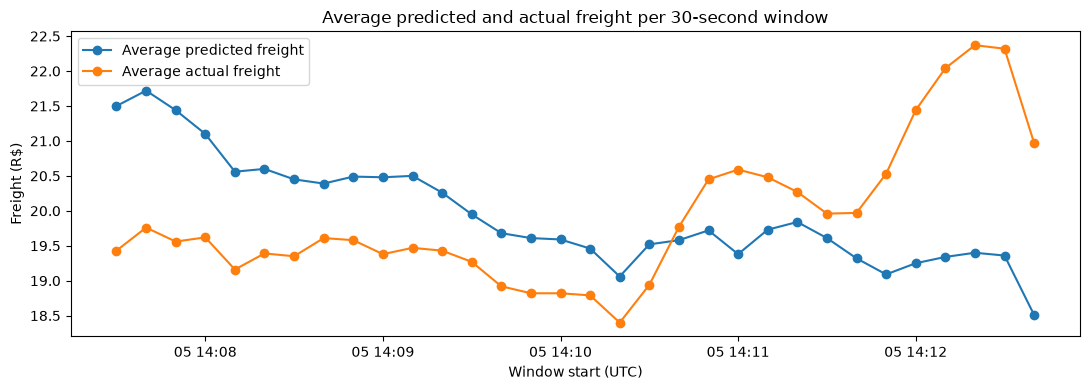

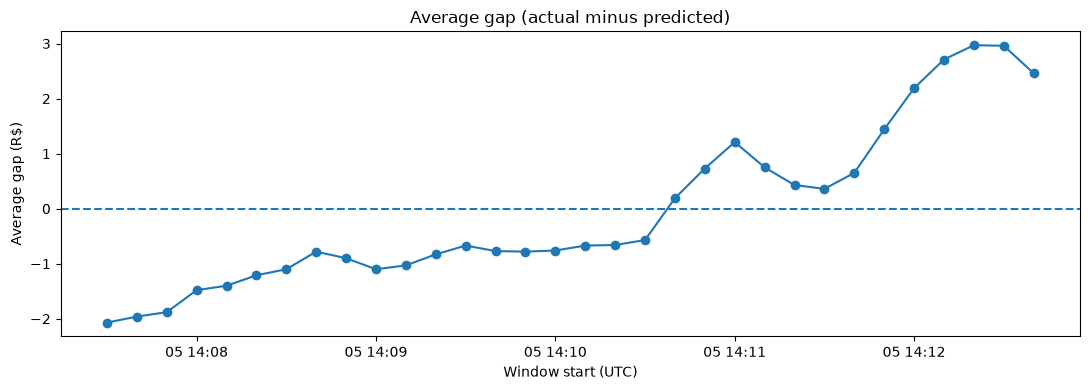

Windows recorded: 36 | plotted: 32


In [110]:
# Keep only mostly complete windows for plotting
plot_windows = final_windows[
    final_windows["items"] >= 2500
].copy()


# Plot predicted and actual freight
plt.figure(figsize=(11, 4))

plt.plot(
    plot_windows["window_start"],
    plot_windows["avg_predicted_freight"],
    marker="o",
    label="Average predicted freight"
)

plt.plot(
    plot_windows["window_start"],
    plot_windows["avg_actual_freight"],
    marker="o",
    label="Average actual freight"
)

plt.ylabel("Freight (R$)")
plt.xlabel("Window start (UTC)")
plt.title("Average predicted and actual freight per 30-second window")
plt.legend()

plt.tight_layout()
plt.show()


# Plot the average prediction gap separately
plt.figure(figsize=(11, 4))

plt.plot(
    plot_windows["window_start"],
    plot_windows["avg_freight_gap"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.ylabel("Average gap (R$)")
plt.xlabel("Window start (UTC)")
plt.title("Average gap (actual minus predicted)")

plt.tight_layout()
plt.show()


# Show how many windows were included
print(
    "Windows recorded:",
    len(final_windows),
    "| plotted:",
    len(plot_windows)
)

**Windowed results**

Our results above show us that the replay produced 36 windows in total, with each window being updated as new batches arrived. We note that most full windows contained 3,000 items (or 6 producer batches). We also see that a few windows only contained 2,500 items due to the fact that the actual producer interval was slightly longer than 5 seconds once send time was included, so occasionally only 5 batches fell inside a 30-second window. Also, we note that the four partial windows at the beginning and end of the replay were left out of the chart.

Given that the producer replays orders in their original purchase order, the later windows also contain later orders. In the early windows, we can see that the predicted freight is around R$2 higher than actual freight on average. Through the middle of the replay, that gap falls to around R$0.6 to R$0.8, before eventually crossing zero. By the time we get to our final windows, our model is under-predicting freight by close to R$3 per item.

Most importantly, we note that is exactly the kind of pattern that the windowed monitoring is meant to pick up. Across the full replay, we see that these over and under-predictions cancel out, so the overall metrics alone would suggest no bias. 

A likely reason for this is the way time is represented in the model. Whilst `purchase_month` captures seasonality within a year, it does not capture the year itself, which means the model cannot directly learn a longer-term increase in freight between 2016 and 2018.